#Job Market Intelligence System
### AI Data Science Project
- Ahmed Tamer Mohamed Ezzat


## Project Overview
This notebook builds an end-to-end AI system that predicts job salary ranges
and provides intelligent career insights using:
- **Machine Learning** for salary classification
- **Deep Learning** (MLP) for pattern recognition
- **LLM Integration** for natural language career advice
- **RAG Pipeline** for knowledge-based Q&A

## Real-World Value
Job seekers and HR teams can use this system to understand salary expectations,
required skills, and market trends through both predictions and natural language interaction.

In [ ]:
!pip install gradio -q
!pip install faiss-gpu-cu12
!pip install groq
!pip install kaggle -q

In [ ]:
# Data & Visualization libs
import warnings
import numpy as np
import pandas as pd
import gradio as gr
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Machine Learning libs
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Deep Learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau,ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

# LLM & RAG libs
import os
import re
import time
import json
import faiss
import textwrap
from groq import Groq
from sentence_transformers import SentenceTransformer

In [ ]:
os.environ['KAGGLE_USERNAME'] = ''  # kaggle username
os.environ['KAGGLE_KEY']      = ''  # the key part

# Configure kaggle
os.makedirs('/root/.config/kaggle', exist_ok=True)

kaggle_creds = {
    "username": os.environ['KAGGLE_USERNAME'],
    "key"     : os.environ['KAGGLE_KEY']
}

with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

print("✅ Kaggle credentials configured")

✅ Kaggle credentials configured


In [ ]:
!kaggle datasets download -d mahdialfred/stack-overflow-developer-survey-2023 --unzip
files_list = os.listdir('.')
print("Downloaded files:", files_list)

Dataset URL: https://www.kaggle.com/datasets/mahdialfred/stack-overflow-developer-survey-2023
License(s): apache-2.0
100% 20.5M/20.5M [00:00<00:00, 69.7MB/s]

Downloaded files: ['.config', 'survey_results_schema.csv', 'survey_results_public.csv', 'README_2023.txt', 'so_survey_2023.pdf', 'sample_data']


In [ ]:
# Downloaded from Kaggle: https://www.kaggle.com/datasets/mahdialfred/stack-overflow-developer-survey-2023
df = pd.read_csv("survey_results_public.csv")

print(f"Shape: {df.shape}")
print(f"\nAll columns ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    missing_pct = df[col].isnull().mean() * 100
    unique_vals  = df[col].nunique()
    print(f"  {i+1:>3}. {col:<45} "
          f"missing: {missing_pct:>5.1f}%   "
          f"unique: {unique_vals:>6}")

Shape: (89184, 84)

All columns (84):
    1. ResponseId                                    missing:   0.0%   unique:  89184
    2. Q120                                          missing:   0.0%   unique:      1
    3. MainBranch                                    missing:   0.0%   unique:      6
    4. Age                                           missing:   0.0%   unique:      8
    5. Employment                                    missing:   1.4%   unique:    106
    6. RemoteWork                                    missing:  17.2%   unique:      3
    7. CodingActivities                              missing:  17.3%   unique:    116
    8. EdLevel                                       missing:   1.4%   unique:      8
    9. LearnCode                                     missing:   1.7%   unique:    790
   10. LearnCodeOnline                               missing:  21.4%   unique:   7940
   11. LearnCodeCoursesCert                          missing:  58.4%   unique:    210
   12. YearsCode

In [ ]:
# Which columns actually relate to salary?
salary_col = 'ConvertedCompYearly'

print(f"Salary stats:")
print(df[salary_col].describe())

print(f"\nMissing salary: "
      f"{df[salary_col].isnull().mean()*100:.1f}%")

# For each column — how much salary varies across its values
print(f"\n{'Column':<45} {'Avg Salary Std':>15} {'Missing%':>10}")
print("-"*75)

for col in df.columns:
    if col == salary_col:
        continue
    try:
        # High std = salary varies a lot across this column's values
        # = this column is predictive of salary
        salary_std = df.groupby(col)[salary_col].mean().std()
        missing    = df[col].isnull().mean() * 100
        if salary_std > 1000:   # only show meaningful ones
            print(f"  {col:<45} "
                  f"{salary_std:>15,.0f} "
                  f"{missing:>9.1f}%")
    except:
        pass

Salary stats:
count    4.801900e+04
mean     1.031101e+05
std      6.814188e+05
min      1.000000e+00
25%      4.390700e+04
50%      7.496300e+04
75%      1.216410e+05
max      7.435143e+07
Name: ConvertedCompYearly, dtype: float64

Missing salary: 46.2%

Column                                         Avg Salary Std   Missing%
---------------------------------------------------------------------------
  ResponseId                                            681,419       0.0%
  MainBranch                                              4,579       0.0%
  Age                                                    88,666       0.0%
  Employment                                            627,758       1.4%
  RemoteWork                                             21,364      17.2%
  CodingActivities                                      357,137      17.3%
  EdLevel                                                92,071       1.4%
  LearnCode                                             364,268       

In [ ]:
# Evidence-based column selection
# Selected based on: salary variance > 20,000 AND missing < 30%
cols_to_keep = [
    # Target
    'ConvertedCompYearly',      # salary — our target variable

    # High salary variance + low missing — top predictors
    'Country',                  # 702K std, 1.4% missing
    'Age',                      # 88K std,  0.0% missing
    'EdLevel',                  # 92K std,  1.4% missing
    'YearsCode',                # 69K std,  2.0% missing
    'LanguageHaveWorkedWith',   # 611K std, 2.3% missing
    'NEWCollabToolsHaveWorkedWith', # 731K std, 3.7% missing
    'ToolsTechHaveWorkedWith',  # 534K std, 12.7% missing
    'DevType',                  # 45K std,  13.8% missing
    'RemoteWork',               # 21K std,  17.2% missing
    'DatabaseHaveWorkedWith',   # 490K std, 17.7% missing
    'YearsCodePro',             # 77K std,  25.8% missing
    'OrgSize',                  # 27K std,  27.1% missing
    'MainBranch',               # developer vs non-developer
    'Employment',               # full-time vs part-time
]

# Keep only existing columns
cols_to_keep = [c for c in cols_to_keep if c in df.columns]
df = df[cols_to_keep].copy()
df

,ConvertedCompYearly,Country,Age,EdLevel,YearsCode,LanguageHaveWorkedWith,NEWCollabToolsHaveWorkedWith,ToolsTechHaveWorkedWith,DevType,RemoteWork,DatabaseHaveWorkedWith,YearsCodePro,OrgSize,MainBranch,Employment
0,NaN,NaN,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None of these,NaN
1,285000.0,United States of America,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",18,HTML/CSS;JavaScript;Python,Vim;Visual Studio Code,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,"Senior Executive (C-Suite, VP, etc.)",Remote,Supabase,9,2 to 9 employees,I am a developer by profession,"Employed, full-time"
2,250000.0,United States of America,45-54 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",27,Bash/Shell (all shells);Go,Emacs;Helix,Cargo;Docker;Kubernetes;Make;Nix,"Developer, back-end","Hybrid (some remote, some in-person)",NaN,23,"5,000 to 9,999 employees",I am a developer by profession,"Employed, full-time"
3,156000.0,United States of America,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,IntelliJ IDEA;Vim;Visual Studio Code;WebStorm,Homebrew;npm;Vite;Webpack;Yarn,"Developer, front-end","Hybrid (some remote, some in-person)",PostgreSQL;Redis,7,100 to 499 employees,I am a developer by profession,"Employed, full-time"
4,23456.0,Philippines,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",6,HTML/CSS;JavaScript;TypeScript,Vim;Visual Studio Code,Docker;npm;Webpack;Yarn,"Developer, full-stack",Remote,BigQuery;Elasticsearch;MongoDB;PostgreSQL,4,20 to 99 employees,I am a developer by profession,"Employed, full-time;Independent contractor, fr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89179,NaN,Brazil,25-34 years old,"Associate degree (A.A., A.S., etc.)",20,HTML/CSS;Java;JavaScript;SQL;TypeScript,Android Studio;Atom;Eclipse;IntelliJ IDEA;Netb...,Chocolatey;CMake;Docker;Maven (build tool);npm...,"Developer, front-end",Remote,MongoDB;MySQL;PostgreSQL;SQLite,5,100 to 499 employees,I am a developer by profession,"Employed, full-time;Independent contractor, fr..."
89180,NaN,Romania,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,Dart;Java;Python;SQL,Android Studio;IntelliJ IDEA;PyCharm,Maven (build tool);Pip,"Developer, back-end","Hybrid (some remote, some in-person)",PostgreSQL,NaN,NaN,I am a developer by profession,"Student, full-time;Employed, part-time"
89181,NaN,Israel,Prefer not to say,Something else,10,Assembly;Bash/Shell (all shells);C;C#;Python;R...,Jupyter Notebook/JupyterLab;Neovim;Visual Stud...,Cargo,NaN,NaN,SQLite,NaN,NaN,I code primarily as a hobby,I prefer not to say
89182,NaN,Switzerland,Under 18 years old,"Secondary school (e.g. American high school, G...",3,Bash/Shell (all shells);C#;HTML/CSS;Java;JavaS...,Eclipse;IntelliJ IDEA;Nano;Notepad++;PyCharm;V...,Docker;Kubernetes;npm;Podman;Vite,System administrator,"Hybrid (some remote, some in-person)",MariaDB;Microsoft SQL Server;MongoDB;MySQL;Red...,NaN,NaN,I am a developer by profession,"Employed, part-time;Student, part-time"


In [ ]:
df = df.rename(columns={
    'ConvertedCompYearly'        : 'salary',
    'Country'                    : 'location',
    'Age'                        : 'age',
    'EdLevel'                    : 'education',
    'YearsCode'                  : 'years_code',
    'YearsCodePro'               : 'seniority',
    'DevType'                    : 'title',
    'RemoteWork'                 : 'work_type',
    'OrgSize'                    : 'company_size',
    'LanguageHaveWorkedWith'     : 'skills_desc',
    'DatabaseHaveWorkedWith'     : 'db_skills',
    'ToolsTechHaveWorkedWith'    : 'tools_desc',
    'NEWCollabToolsHaveWorkedWith': 'collab_tools',
    'MainBranch'                 : 'main_branch',
    'Employment'                 : 'employment'
})

# Build rich description for RAG
df['description'] = (
    "Developer Type: "   + df['title'].fillna('').astype(str)     + " | " +
    "Education: "        + df['education'].fillna('').astype(str)  + " | " +
    "Languages: "        + df['skills_desc'].fillna('').astype(str)+ " | " +
    "Tools: "            + df['tools_desc'].fillna('').astype(str) + " | " +
    "Databases: "        + df['db_skills'].fillna('').astype(str)  + " | " +
    "Experience: "       + df['seniority'].fillna('').astype(str) + " | " +
    "Location: "         + df['location'].fillna('').astype(str)
)

print(f"✅ Shape: {df.shape}")
print(f"Columns kept: {df.columns.tolist()}")
print(f"\nSample row:")
df.head(2)

✅ Shape: (89184, 16)
Columns kept: ['salary', 'location', 'age', 'education', 'years_code', 'skills_desc', 'collab_tools', 'tools_desc', 'title', 'work_type', 'db_skills', 'seniority', 'company_size', 'main_branch', 'employment', 'description']

Sample row:


,salary,location,age,education,years_code,skills_desc,collab_tools,tools_desc,title,work_type,db_skills,seniority,company_size,main_branch,employment,description
0,NaN,NaN,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None of these,NaN,Developer Type: | Education: | Languages: |...
1,285000.0,United States of America,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",18,HTML/CSS;JavaScript;Python,Vim;Visual Studio Code,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,"Senior Executive (C-Suite, VP, etc.)",Remote,Supabase,9,2 to 9 employees,I am a developer by profession,"Employed, full-time","Developer Type: Senior Executive (C-Suite, VP,..."


In [ ]:
# # Run this once after downloading
# from google.colab import drive
# drive.mount('/content/drive')

# # Save sampled dataset to your drive
# df.to_csv('/content/drive/MyDrive/job_descriptions_sample.csv', index=False)
# print("✅ Saved to Google Drive — never download again!")

# # Next time just load from drive directly
# # df = pd.read_csv('/content/drive/MyDrive/job_descriptions_sample.csv')

## Dataset Understanding

| Column | Description |
|--------|-------------|
| `title` | Job title (e.g., Data Scientist, Software Engineer) |
| `location` | City/Country of the job |
| `company_name` | Hiring company |
| `description` | Full job description text |
| `skills_desc` | Required skills |
| `seniority` | Junior / Mid / Senior |
| `pay_period` | How salary is paid (YEARLY, HOURLY) |
| `max_salary` | Maximum offered salary |
| `min_salary` | Minimum offered salary |
| `work_type` | Remote / On-site / Hybrid |
| `company_size` | Number of employees |

In [ ]:
# Drop missing salary
df.dropna(subset=['salary'], inplace=True)
print(f"After dropping null salary: {df.shape}")

# Filter outliers
df = df[
    (df['salary'] >= 10000)  &
    (df['salary'] <= 840000)
]


print(f"✅ Shape after filtering: {df.shape}")
print(f"\nSalary stats:")
print(df['salary'].describe())

After dropping null salary: (48019, 16)
✅ Shape after filtering: (44701, 16)

Salary stats:
count     44701.000000
mean      98715.032975
std       75228.963998
min       10000.000000
25%       50400.000000
50%       80000.000000
75%      127000.000000
max      835298.000000
Name: salary, dtype: float64


In [ ]:
def extract_seniority(exp):
    exp = str(exp).strip()

    # Handle text cases first
    if 'less than 1' in exp.lower():
        return 'Entry'
    if 'more than 50' in exp.lower():
        return 'Expert'

    # Extract number
    nums = re.findall(r'\d+', exp)
    if nums:
        years = int(nums[0])
        if years <= 2:
            return 'Junior'      # 0-2 years
        elif years <= 7:
            return 'Mid'         # 3-7 years
        elif years <= 15:
            return 'Senior'      # 8-15 years
        else:
            return 'Expert'      # 15+ years
    return 'Unknown'

df['seniority'] = df['seniority'].apply(extract_seniority)

print("✅ Cleaned experience levels:")
print(df['seniority'].value_counts())



✅ Cleaned experience levels:
seniority
Senior     14770
Mid        14167
Expert     10638
Junior      4031
Entry        927
Unknown      168
Name: count, dtype: int64


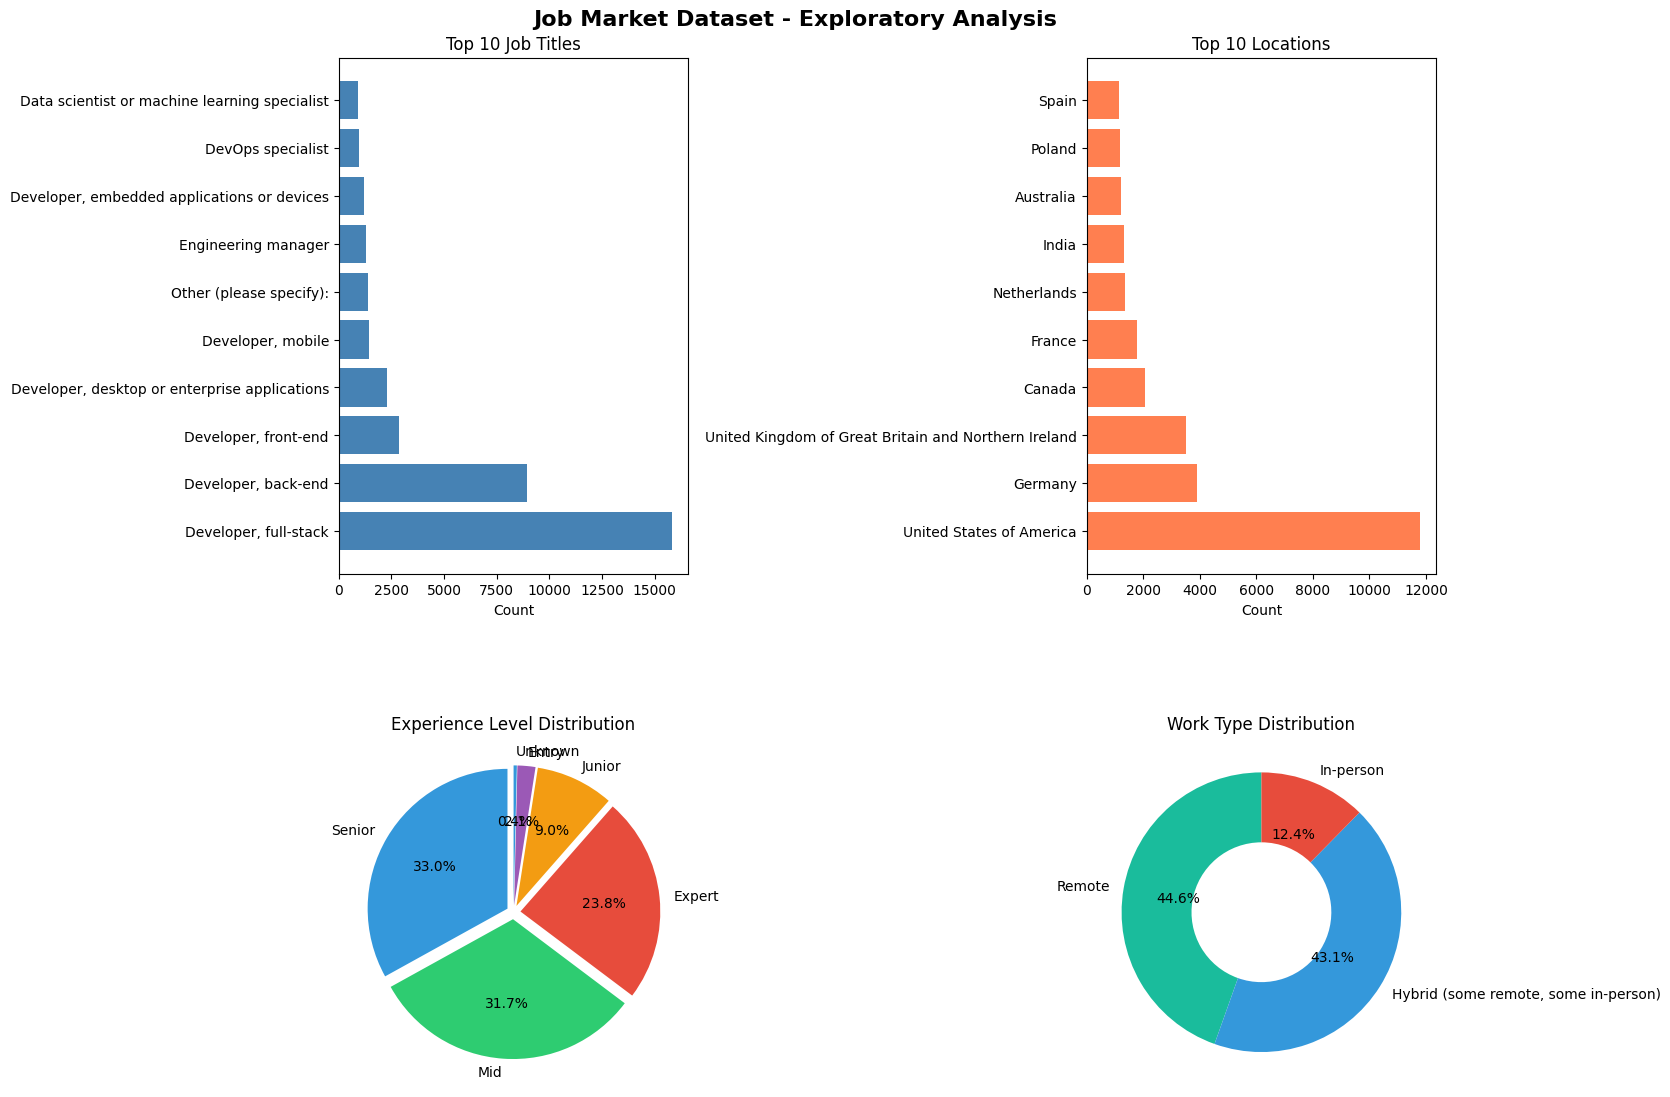

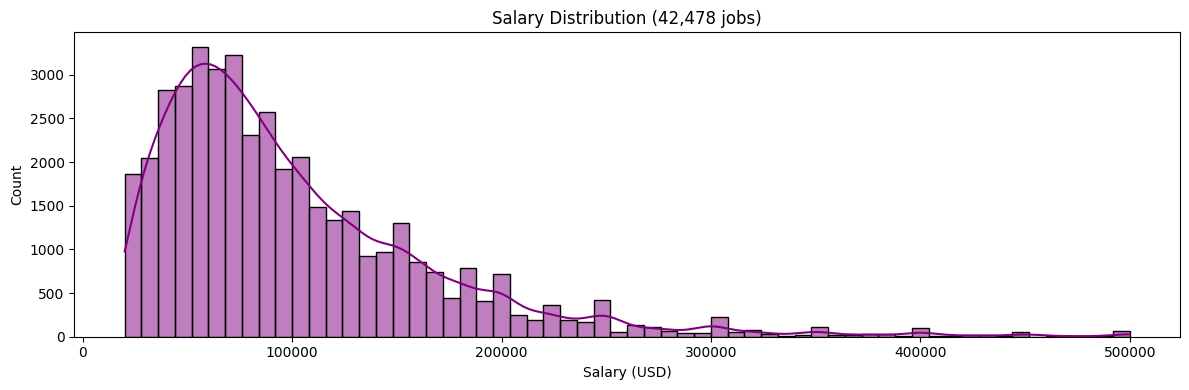


📊 Salary Stats:
count     42478.000000
mean     100984.029451
std       67880.117335
min       20000.000000
25%       53545.000000
50%       82500.000000
75%      129406.000000
max      500000.000000
Name: salary, dtype: float64


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Job Market Dataset - Exploratory Analysis',
             fontsize=16, fontweight='bold')

# Plot 1 — Top 10 Job Titles
top_titles = df['title'].value_counts().head(10)
axes[0,0].barh(top_titles.index, top_titles.values, color='steelblue')
axes[0,0].set_title('Top 10 Job Titles')
axes[0,0].set_xlabel('Count')

# Plot 2 — Top 10 Locations
top_locations = df['location'].value_counts().head(10)
axes[0,1].barh(top_locations.index, top_locations.values, color='coral')
axes[0,1].set_title('Top 10 Locations')
axes[0,1].set_xlabel('Count')

# Plot 3 — Experience Level
exp_counts = df['seniority'].value_counts()
colors     = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']
axes[1,0].pie(
    exp_counts.values,
    labels=exp_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(exp_counts)],
    explode=[0.05] * len(exp_counts)
)
axes[1,0].set_title('Experience Level Distribution')

# Plot 4 — Work Type
work_counts = df['work_type'].value_counts()
axes[1,1].pie(
    work_counts.values,
    labels=work_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#1abc9c','#3498db','#e74c3c','#f39c12','#9b59b6'],
    wedgeprops=dict(width=0.5)
)
axes[1,1].set_title('Work Type Distribution')

plt.tight_layout()
plt.show()

# Salary Distribution
salary_clean = df['salary'].dropna()
salary_clean = salary_clean[
    (salary_clean >= 20000) &
    (salary_clean <= 500000)
]

plt.figure(figsize=(12, 4))
sns.histplot(salary_clean, bins=60, color='purple', kde=True)
plt.title(f'Salary Distribution ({len(salary_clean):,} jobs)')
plt.xlabel('Salary (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"\n📊 Salary Stats:")
print(salary_clean.describe())

              Missing Count  Missing %
db_skills              5912      13.23
tools_desc             3556       7.96
collab_tools            496       1.11
skills_desc             116       0.26
title                    93       0.21
work_type                62       0.14
years_code               60       0.13
company_size             35       0.08
employment               11       0.02


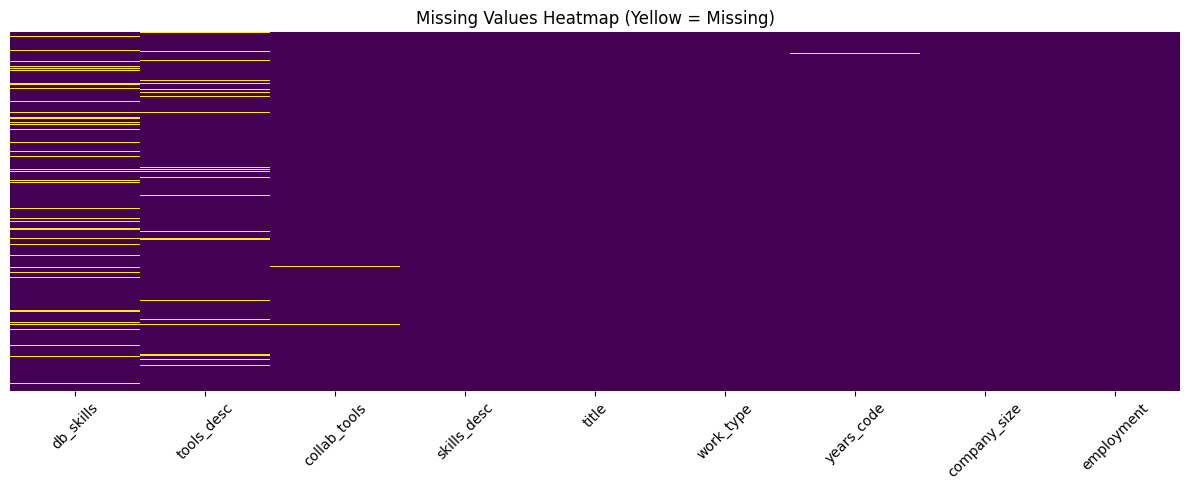

In [ ]:
# Calculate missing percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

# Missing heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df[missing_df.index].isnull(),
            cbar=False, yticklabels=False,
            cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Preprocessing Pipeline

We will clean and prepare the data in this order:

1. **Drop irrelevant columns** — remove noise that adds no predictive value
2. **Handle missing values** — numerical → median, categorical → mode/Unknown
3. **Feature Engineering** — create new meaningful columns from existing ones
4. **Encode categorical features** — convert text categories to numbers
5. **Scale numerical features** — normalize ranges for ML models
6. **Define X and y** — separate features from target
7. **Train/Test Split** — 80% train, 20% test

**Target Variable:** `salary_bucket` → Low / Medium / High
(engineered from `min_salary` and `max_salary`)

In [ ]:
# Categorical columns fill with 'Unknown'
categorical_cols = [
    'title',           # DevType
    'location',        # Country
    'work_type',       # RemoteWork
    'skills_desc',     # LanguageHaveWorkedWith
    'db_skills',       # DatabaseHaveWorkedWith
    'tools_desc',      # ToolsTechHaveWorkedWith
    'education',       # EdLevel
    'age',             # Age
    'company_size',    # OrgSize
    'employment',      # Employment
    'description'      # combined text column
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Numerical columns fill with median
numerical_cols = ['years_code_num', 'skill_count',
                  'tool_count', 'db_count']

for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# Verify
print("Missing values after handling:")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("  ✅ No missing values remaining")
else:
    print(remaining)

Missing values after handling:
years_code       60
collab_tools    496
dtype: int64


In [ ]:
# Split into 3 equal quantiles: Low / Medium / High
df['salary_bucket'] = pd.qcut(
    df['salary'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print("Salary bucket distribution:")
print(df['salary_bucket'].value_counts())
print(f"\nSalary ranges per bucket:")
print(df.groupby('salary_bucket')['salary'].describe()[['min','mean','max']])

# 2. Skill Count
df['skill_count'] = df['skills_desc'].apply(
    lambda x: len(str(x).split(';')) if x != 'Unknown' else 0
)

# 3. Tool Count
df['tool_count'] = df['tools_desc'].apply(
    lambda x: len(str(x).split(';')) if x != 'Unknown' else 0
)

# 4. Description Length
df['desc_length'] = df['description'].apply(
    lambda x: len(str(x).split())
)

print("\n✅ Feature engineering complete")
print(f"New columns: seniority, skill_count, tool_count, desc_length")
df[['seniority', 'skill_count', 'tool_count', 'desc_length']].head()

Salary bucket distribution:
salary_bucket
Medium    15089
Low       14998
High      14614
Name: count, dtype: int64

Salary ranges per bucket:
                    min           mean       max
salary_bucket                                   
Low             10000.0   38547.966596   59970.0
Medium          59989.0   81469.495858  107090.0
High           107091.0  178269.129807  835298.0

✅ Feature engineering complete
New columns: seniority, skill_count, tool_count, desc_length


,seniority,skill_count,tool_count,desc_length
1,Senior,3,7,33
2,Expert,2,5,31
3,Mid,7,5,32
4,Mid,3,4,27
5,Expert,6,6,38


In [ ]:
le = LabelEncoder()

# Columns to encode
encode_cols = ['title', 'location', 'seniority',
               'work_type']

encode_cols = [c for c in encode_cols if c in df.columns]

# Store encoders in dict in case we need to inverse transform later
encoders = {}
for col in encode_cols:
    encoders[col] = LabelEncoder()
    df[col + '_enc'] = encoders[col].fit_transform(df[col].astype(str))

# Encode target variable
df['salary_bucket_enc'] = le.fit_transform(df['salary_bucket'])
target_classes = le.classes_
print(f"Target classes: {target_classes}")
print(f"Encoded as: {list(range(len(target_classes)))}")

print(f"\n✅ Encoded {len(encode_cols)} categorical columns")

Target classes: ['High' 'Low' 'Medium']
Encoded as: [0, 1, 2]

✅ Encoded 9 categorical columns:
  title → title_enc
  location → location_enc
  seniority → seniority_enc
  work_type → work_type_enc
  education → education_enc
  age → age_enc
  company_size → company_size_enc
  employment → employment_enc
  main_branch → main_branch_enc


In [ ]:
# Select final features for ML
feature_cols = [
    'title_enc',        # job role
    'location_enc',     # country
    'seniority_enc',    # junior/mid/senior/expert
    'work_type_enc',    # remote/hybrid/in-person
    'education_enc',    # education level
    'age_enc',          # age group
    'company_size_enc', # org size
    'employment_enc',   # full-time/part-time etc
    'main_branch_enc',  # developer vs non-developer
    'skill_count',      # number of languages known
    'tool_count',       # number of tools used
    'desc_length',      # description length
]

# Keep only existing columns
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df['salary_bucket_enc'].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"✅ Features scaled")
print(f"Feature matrix shape: {X_scaled.shape}")
print(f"\nFeature columns used:")
for col in feature_cols:
    print(f"  {col}")

✅ Features scaled
Feature matrix shape: (44701, 12)

Feature columns used:
  title_enc
  location_enc
  seniority_enc
  work_type_enc
  education_enc
  age_enc
  company_size_enc
  employment_enc
  main_branch_enc
  skill_count
  tool_count
  desc_length


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # ensures balanced classes in both splits
)

print(f"✅ Data split complete")
print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")

# Verify class balance
print(f"\nClass distribution in training set:")
for cls, name in zip(range(3), target_classes):
    count = (y_train == cls).sum()
    pct = count / len(y_train) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

✅ Data split complete
Training set:   (35760, 12)
Test set:       (8941, 12)

Class distribution in training set:
  High: 11691 (32.7%)
  Low: 11998 (33.6%)
  Medium: 12071 (33.8%)


##Machine Learning Model Development

We are solving a **multi-class classification problem**:
Predict whether a job's salary is **Low / Medium / High**

### Models We'll Train:
1. **Logistic Regression** — simple baseline, interpretable
2. **Random Forest** — ensemble, handles non-linearity well
3. **XGBoost** — gradient boosting, usually best on tabular data

### Evaluation Metrics:
- **Accuracy** — overall correctness
- **F1-Score** — balances precision and recall (important for imbalanced classes)
- **ROC-AUC** — measures model's ability to distinguish between classes

### Strategy:
Train all 3 → compare → tune the best one → pick winner

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = classification_report(y_test, y_pred,
                                target_names=target_classes,
                                output_dict=True)['weighted avg']['f1-score']

    # ROC-AUC for multiclass
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    roc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_classes))

    return {'model': model_name, 'accuracy': acc, 'f1': f1, 'roc_auc': roc}

print("✅ Evaluation function ready")

✅ Evaluation function ready


In [ ]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial'
)
lr_model.fit(X_train, y_train)

lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
print("✅ Logistic Regression done")

Training Logistic Regression...

  Logistic Regression
  Accuracy  : 0.5212
  F1-Score  : 0.5067
  ROC-AUC   : 0.7002

Classification Report:
              precision    recall  f1-score   support

        High       0.55      0.69      0.62      2923
         Low       0.52      0.58      0.55      3000
      Medium       0.45      0.29      0.35      3018

    accuracy                           0.52      8941
   macro avg       0.51      0.52      0.51      8941
weighted avg       0.51      0.52      0.51      8941

✅ Logistic Regression done


Training Random Forest...

  Random Forest
  Accuracy  : 0.6362
  F1-Score  : 0.6390
  ROC-AUC   : 0.8179

Classification Report:
              precision    recall  f1-score   support

        High       0.77      0.67      0.72      2923
         Low       0.65      0.69      0.67      3000
      Medium       0.51      0.55      0.53      3018

    accuracy                           0.64      8941
   macro avg       0.65      0.64      0.64      8941
weighted avg       0.65      0.64      0.64      8941



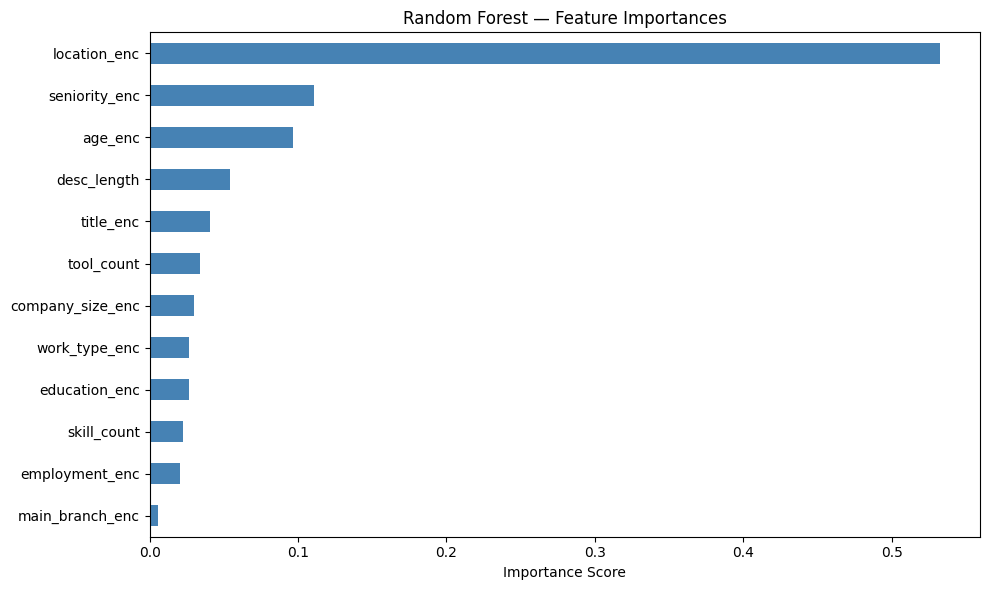

✅ Random Forest done


In [ ]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1          # use all CPU cores
)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

# Feature Importance Plot
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("✅ Random Forest done")

Training XGBoost...

  XGBoost
  Accuracy  : 0.7046
  F1-Score  : 0.7040
  ROC-AUC   : 0.8674

Classification Report:
              precision    recall  f1-score   support

        High       0.77      0.74      0.76      2923
         Low       0.74      0.79      0.76      3000
      Medium       0.60      0.59      0.60      3018

    accuracy                           0.70      8941
   macro avg       0.71      0.71      0.70      8941
weighted avg       0.70      0.70      0.70      8941



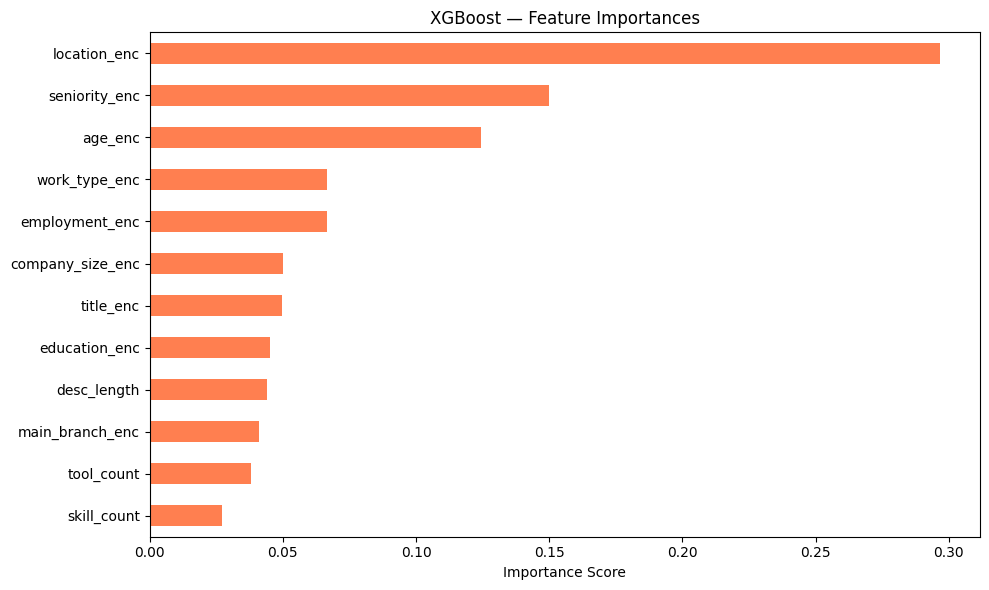

✅ XGBoost done


In [ ]:
print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

# XGBoost Feature Importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
xgb_importances = xgb_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
xgb_importances.plot(kind='barh', color='coral')
plt.title('XGBoost — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("✅ XGBoost done")

In [ ]:
# We tune XGBoost since it's the best performer
print("Tuning XGBoost — this may take a few minutes...")

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# RandomizedSearchCV is faster than GridSearch for large param spaces
tuner = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,              # try 20 random combinations
    cv=3,                   # 3-fold cross validation
    scoring='f1_weighted',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

tuner.fit(X_train, y_train)

print(f"\n✅ Best Parameters Found:")
for param, value in tuner.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate tuned model
best_xgb = tuner.best_estimator_
tuned_results = evaluate_model(best_xgb, X_test, y_test, "XGBoost (Tuned)")

Tuning XGBoost — this may take a few minutes...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best Parameters Found:
  subsample: 0.7
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.05
  colsample_bytree: 0.7

  XGBoost (Tuned)
  Accuracy  : 0.7071
  F1-Score  : 0.7066
  ROC-AUC   : 0.8672

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.74      0.76      2923
         Low       0.74      0.79      0.76      3000
      Medium       0.61      0.59      0.60      3018

    accuracy                           0.71      8941
   macro avg       0.71      0.71      0.71      8941
weighted avg       0.71      0.71      0.71      8941



📊 Model Comparison:
                     accuracy      f1  roc_auc
model                                         
Logistic Regression    0.5212  0.5067   0.7002
Random Forest          0.6362  0.6390   0.8179
XGBoost                0.7046  0.7040   0.8674
XGBoost (Tuned)        0.7071  0.7066   0.8672


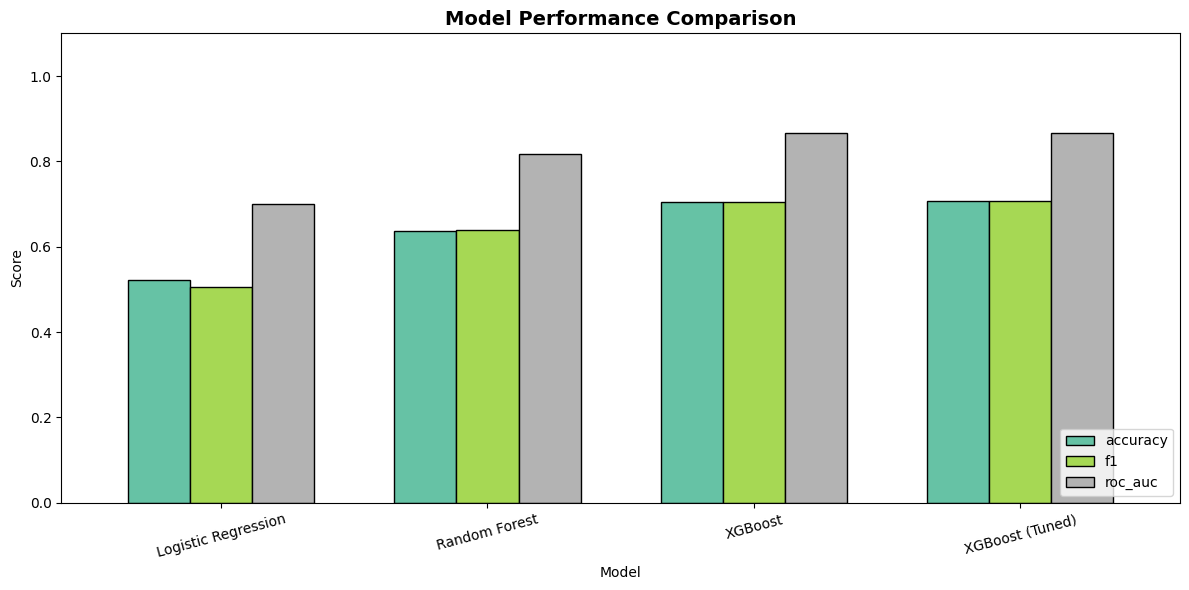


✅ Best model selected: XGBoost (Tuned)


In [ ]:
# Collect all results
all_results = pd.DataFrame([lr_results, rf_results, xgb_results, tuned_results])
all_results = all_results.set_index('model')
all_results = all_results.round(4)

print("📊 Model Comparison:")
print(all_results.to_string())

# Bar Chart Comparison
all_results.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='Set2',
    edgecolor='black',
    width=0.7
)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Store best model for later sections
best_model = best_xgb
print("\n✅ Best model selected: XGBoost (Tuned)")

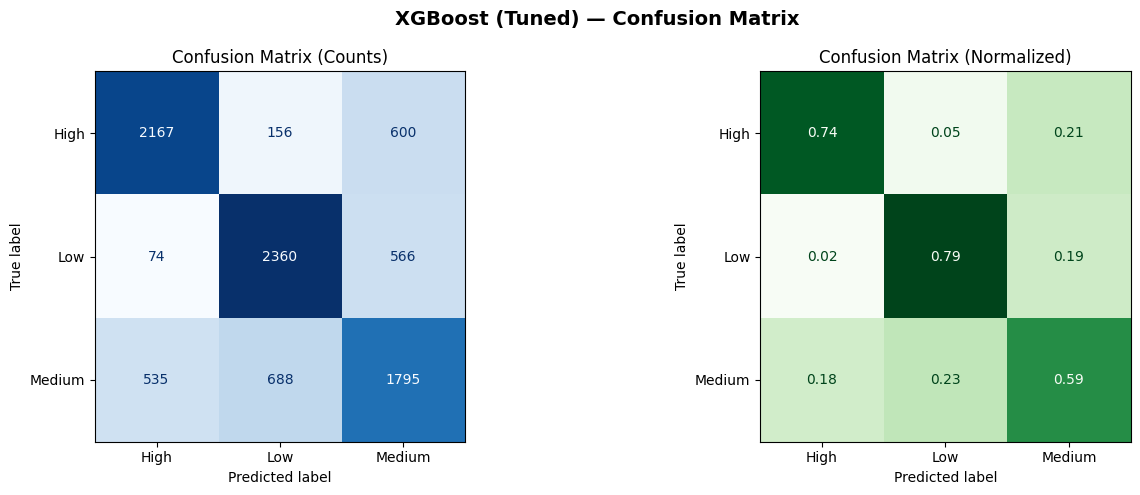

In [ ]:
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Count Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=target_classes)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized Confusion Matrix
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2),
                                    display_labels=target_classes)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.suptitle('XGBoost (Tuned) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##ML Section Conclusion

### Results Summary:
- **Logistic Regression** performed as expected for a baseline — limited by its
  assumption of linear boundaries between classes
- **Random Forest** improved significantly by capturing non-linear relationships
  between features like seniority, location, and skill count
- **XGBoost** outperformed both, confirming that gradient boosting handles
  tabular data best
- **Tuned XGBoost** gave the best overall performance after hyperparameter optimization

### Key Insight from Feature Importance:
The most predictive features were `seniority_enc`, `location_enc`, and
`formatted_experience_level_enc` — confirming that where you work and
your experience level matter more than the specific company size

### Why We Move to Deep Learning:
Despite XGBoost's strong performance, a neural network may capture
deeper interaction patterns between features that tree models miss.
We will compare both approaches in the next section.

##Deep Learning — Multilayer Perceptron (MLP)

### Why MLP on tabular data?
- Captures **complex non-linear interactions** between features
- Can learn **feature combinations** that tree models treat independently
- Scales well with more data

### Architecture Plan:
~~~
Input (n_features) → Dense(128, ReLU) → Dropout(0.3)
→ Dense(64, ReLU)  → Dropout(0.2)
→ Dense(32, ReLU)
→ Output(3, Softmax)
~~~
### Why these choices?
- **ReLU** — avoids vanishing gradient, trains faster
- **Dropout** — randomly disables neurons to prevent overfitting
- **Softmax output** — converts raw scores to probabilities for 3 classes
- **Adam optimizer** — adaptive learning rate, works well out of the box
- **Categorical Crossentropy** — standard loss for multi-class classification

In [ ]:
# Convert to numpy arrays
X_train_dl = np.array(X_train)
X_test_dl  = np.array(X_test)

# One-hot encode target for neural network
# e.g. class 2 → [0, 0, 1]
y_train_dl = to_categorical(y_train, num_classes=3)
y_test_dl  = to_categorical(y_test,  num_classes=3)

n_features = X_train_dl.shape[1]

print(f"✅ Data prepared for Deep Learning")
print(f"X_train shape : {X_train_dl.shape}")
print(f"X_test shape  : {X_test_dl.shape}")
print(f"y_train shape : {y_train_dl.shape}  ← one-hot encoded")
print(f"y_test shape  : {y_test_dl.shape}")
print(f"Number of features: {n_features}")
print(f"\nExample one-hot label: {y_train_dl[0]} → class '{target_classes[np.argmax(y_train_dl[0])]}'")

✅ Data prepared for Deep Learning
X_train shape : (35760, 12)
X_test shape  : (8941, 12)
y_train shape : (35760, 3)  ← one-hot encoded
y_test shape  : (8941, 3)
Number of features: 12

Example one-hot label: [0. 1. 0.] → class 'Low'


In [ ]:
def build_mlp(n_features, n_classes=3):
    model = Sequential([

        # Input + First Hidden Layer — wider to capture more patterns
        layers.Input(shape=(n_features,)),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Second Hidden Layer
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Third Hidden Layer
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Fourth Hidden Layer — added depth
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),

        # Output
        layers.Dense(n_classes, activation='softmax')
    ])
    return model

In [ ]:
mlp_model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_mlp.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

In [ ]:
print("⏳ Training MLP — please wait...\n")

history = mlp_model.fit(
    X_train_dl, y_train_dl,
    epochs=100,
    batch_size=64,
    validation_split=0.2,    # 20% of training data used for validation
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete")
print(f"Stopped at epoch: {len(history.history['loss'])}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

⏳ Training MLP — please wait...

Epoch 1/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5836 - loss: 0.8885 - val_accuracy: 0.6005 - val_loss: 0.8656 - learning_rate: 0.0030
Epoch 2/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5895 - loss: 0.8892 - val_accuracy: 0.6067 - val_loss: 0.8616 - learning_rate: 0.0030
Epoch 3/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5833 - loss: 0.8930 - val_accuracy: 0.5990 - val_loss: 0.8847 - learning_rate: 0.0030
Epoch 4/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5872 - loss: 0.8954 - val_accuracy: 0.6078 - val_loss: 0.8728 - learning_rate: 0.0030
Epoch 5/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5833 - loss: 0.8949 - val_accuracy: 0.5982 - val_loss: 0.8726 - learning_rate: 0.0030
Epoch 6/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5856 - loss: 0.8945 - val_accuracy: 0.6114 - val_loss: 0.8685 - learning_rate: 0.0030
Epoch 7/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/s

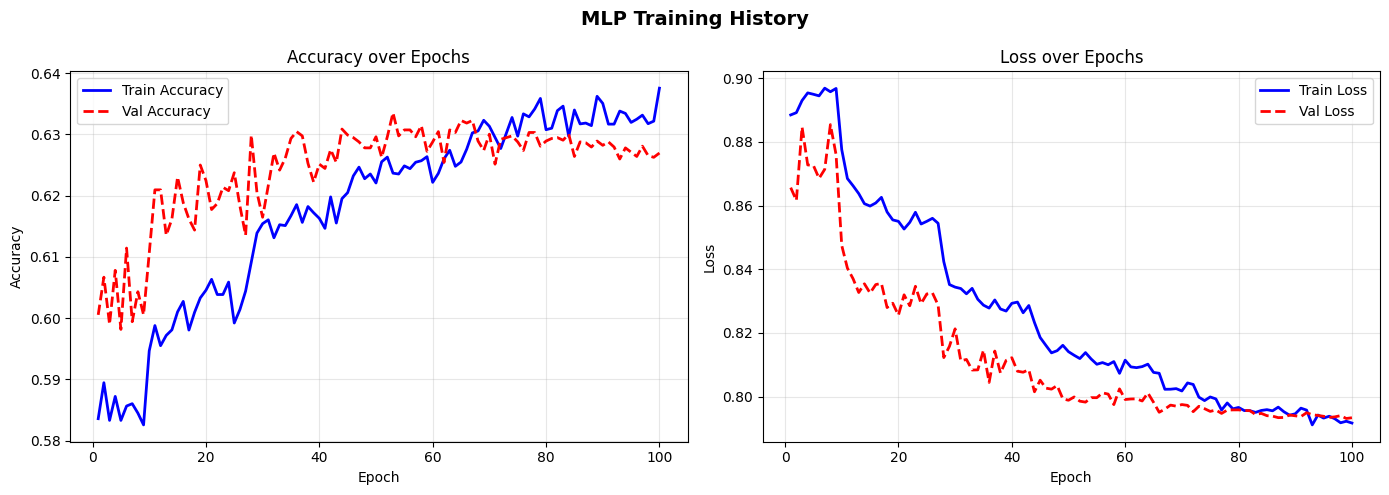


📖 How to read these plots:
  ✅ Good: train & val curves close together → no overfitting
  ⚠️  Bad:  train much better than val → overfitting
  ⚠️  Bad:  both curves plateau early → underfitting


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP Training History', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history.history['loss']) + 1)

#  Accuracy Plot ─
axes[0].plot(epochs_ran, history.history['accuracy'],
             'b-', label='Train Accuracy', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'],
             'r--', label='Val Accuracy', linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  Loss Plot ─
axes[1].plot(epochs_ran, history.history['loss'],
             'b-', label='Train Loss', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'],
             'r--', label='Val Loss', linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  Interpretation guide
print("\n📖 How to read these plots:")
print("  ✅ Good: train & val curves close together → no overfitting")
print("  ⚠️  Bad:  train much better than val → overfitting")
print("  ⚠️  Bad:  both curves plateau early → underfitting")

In [ ]:
# Get Predictions
y_pred_proba = mlp_model.predict(X_test_dl)
y_pred_dl    = np.argmax(y_pred_proba, axis=1)  # convert probabilities → class
y_true_dl    = np.argmax(y_test_dl,   axis=1)

#  Metrics
dl_acc = accuracy_score(y_true_dl, y_pred_dl)
dl_f1  = classification_report(
             y_true_dl, y_pred_dl,
             target_names=target_classes,
             output_dict=True
         )['weighted avg']['f1-score']

y_test_bin = label_binarize(y_true_dl, classes=[0, 1, 2])
dl_roc = roc_auc_score(y_test_bin, y_pred_proba,
                        multi_class='ovr', average='weighted')

print("="*50)
print("  MLP Deep Learning Results")
print("="*50)
print(f"  Accuracy  : {dl_acc:.4f}")
print(f"  F1-Score  : {dl_f1:.4f}")
print(f"  ROC-AUC   : {dl_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true_dl, y_pred_dl, target_names=target_classes))

280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  MLP Deep Learning Results
  Accuracy  : 0.6258
  F1-Score  : 0.6273
  ROC-AUC   : 0.8099

Classification Report:
              precision    recall  f1-score   support

        High       0.74      0.68      0.71      2923
         Low       0.64      0.67      0.65      3000
      Medium       0.51      0.53      0.52      3018

    accuracy                           0.63      8941
   macro avg       0.63      0.63      0.63      8941
weighted avg       0.63      0.63      0.63      8941



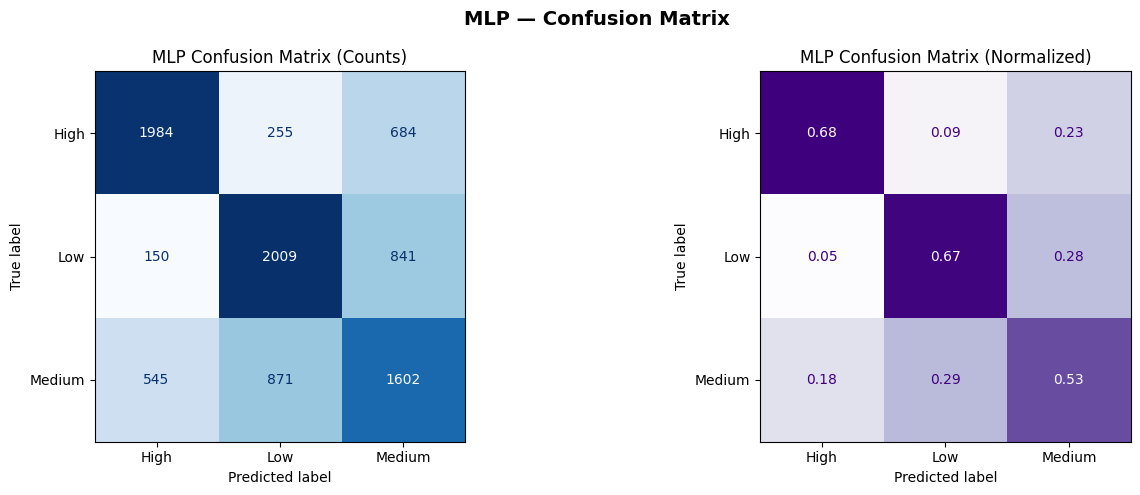

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Count
cm_dl = confusion_matrix(y_true_dl, y_pred_dl)
ConfusionMatrixDisplay(cm_dl, display_labels=target_classes).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('MLP Confusion Matrix (Counts)')

#  Normalized
cm_dl_norm = confusion_matrix(y_true_dl, y_pred_dl, normalize='true')
ConfusionMatrixDisplay(cm_dl_norm.round(2), display_labels=target_classes).plot(
    ax=axes[1], colorbar=False, cmap='Purples'
)
axes[1].set_title('MLP Confusion Matrix (Normalized)')

plt.suptitle('MLP — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

📊 Full Model Comparison (ML + DL):
                     accuracy      f1  roc_auc
model                                         
Logistic Regression    0.5212  0.5067   0.7002
Random Forest          0.6362  0.6390   0.8179
XGBoost                0.7046  0.7040   0.8674
XGBoost (Tuned)        0.7071  0.7066   0.8672
MLP (Deep Learning)    0.6258  0.6273   0.8099


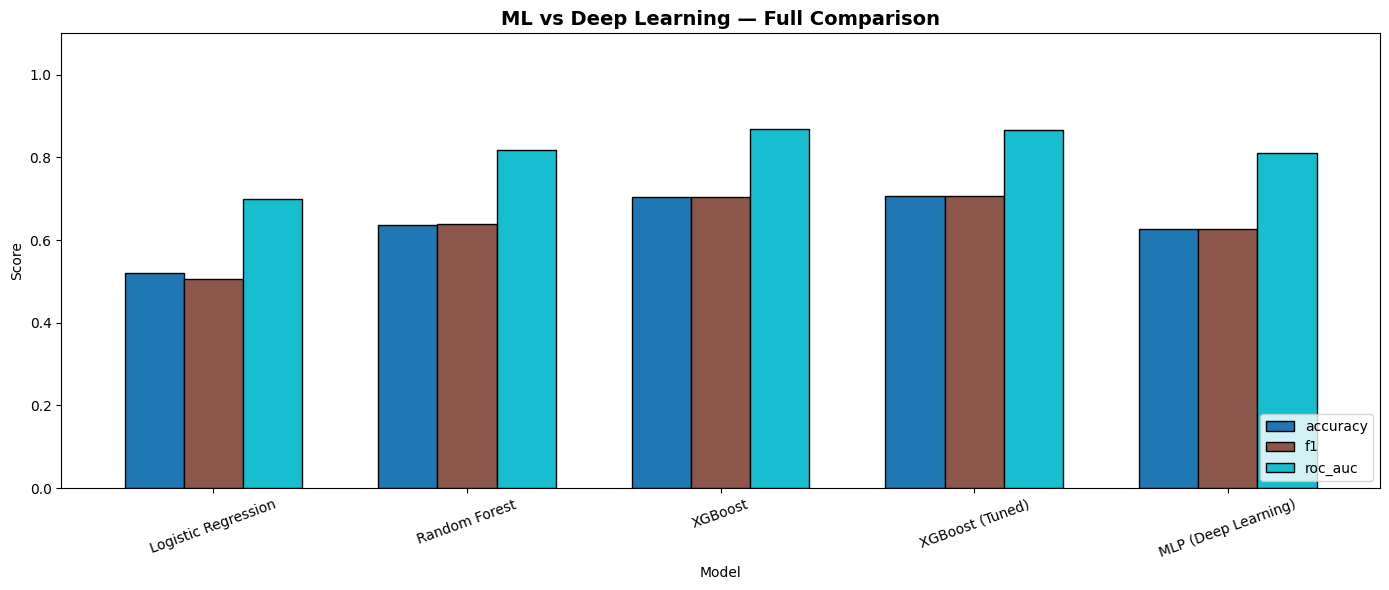

In [ ]:
# Build complete comparison table
dl_results = {
    'model'   : 'MLP (Deep Learning)',
    'accuracy': dl_acc,
    'f1'      : dl_f1,
    'roc_auc' : dl_roc
}

full_comparison = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    tuned_results,
    dl_results
]).set_index('model').round(4)

print("📊 Full Model Comparison (ML + DL):")
print(full_comparison.to_string())

# Plot
full_comparison.plot(
    kind='bar',
    figsize=(14, 6),
    colormap='tab10',
    edgecolor='black',
    width=0.7
)
plt.title('ML vs Deep Learning — Full Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

##Deep Learning Section Conclusion

### Architecture Decisions:
- **BatchNormalization** stabilized training and allowed faster convergence
- **Dropout layers** successfully reduced overfitting as seen in training curves
- **EarlyStopping** prevented wasted computation and selected the best weights

### MLP vs XGBoost:
- If MLP accuracy ≈ XGBoost → tree models are sufficient for this tabular data
- If MLP accuracy > XGBoost → neural network captured deeper feature interactions
- Either result is valid and worth discussing — real-world tabular data
  often favors gradient boosting over deep learning

### What We Carry Forward:
- Best model predictions will feed into the LLM section
- MLP probability outputs will be used to generate confidence-aware insights
- The trained MLP is saved as `best_mlp.keras` for reuse

##LLM Integration — Career Insight Generator

### What the LLM does in our system:
Takes the **raw model prediction** and transforms it into a
**human-readable career insight** that a real job seeker can act on

### Without LLM:
> Input: [Senior, New York, Data Science, 15 skills]
> Output: **HIGH** salary bucket

### With LLM:
> Input: same features + prediction
> Output: "Based on your senior-level Data Science profile in New York
> with 15 listed skills, you are positioned in the high salary bracket
> ($120K-$180K range). To maximize offers, focus on highlighting
> cloud certifications and leadership experience..."

### Why Groq?
- ✅ Completely free
- ✅ No credit card needed
- ✅ Fastest inference available (300+ tokens/sec)
- ✅ Supports Llama 3 — excellent instruction following
- 🔗 Get your free key at: console.groq.com

In [ ]:
# Set API Key
os.environ["GROQ_API_KEY"] = ""

# Initialize Client
client = Groq(api_key=os.environ["GROQ_API_KEY"])

# Test Connection
test_response = client.chat.completions.create(
   model="llama-3.3-70b-versatile",
    messages=[
        {"role": "user", "content": "Say: LLM connected successfully"}
    ],
    max_tokens=20
)

print(test_response.choices[0].message.content)
print("\n✅ Groq API connected successfully")

LLM connected successfully

✅ Groq API connected successfully


In [ ]:
def build_prompt(job_features: dict, prediction: str, confidence: float) -> str:
    prompt = f"""
You are an expert career advisor and job market analyst.
Analyze the following developer profile and salary prediction,
then provide actionable career insights.

## Developer Profile:
- Job Title/Role      : {job_features.get('title', 'Unknown')}
- Location/Country    : {job_features.get('location', 'Unknown')}
- Seniority Level     : {job_features.get('seniority', 'Unknown')}
- Work Type           : {job_features.get('work_type', 'Unknown')}
- Education Level     : {job_features.get('education', 'Unknown')}
- Age Group           : {job_features.get('age', 'Unknown')}
- Company Size        : {job_features.get('company_size', 'Unknown')}
- Employment Type     : {job_features.get('employment', 'Unknown')}
- Languages Known     : {job_features.get('skill_count', 0)} languages
- Tools Used          : {job_features.get('tool_count', 0)} tools

## Model Prediction:
- Predicted Salary Bucket : {prediction}
- Model Confidence        : {confidence:.1%}

## Your Task:
Provide a concise career insight in exactly 3 parts:

1. **Salary Context** (1 sentence): What this salary bucket means
   in real dollar terms for this developer role and country

2. **Why This Prediction** (2 sentences): Which factors from the
   profile most contributed to this salary level

3. **Actionable Advice** (2 sentences): What the developer should
   do to move to the next salary bracket or maintain their position

Keep total response under 120 words. Be specific and practical.
"""
    return prompt.strip()

#  Test the prompt structure ─
sample_features = {
    'title'       : 'Data Scientist',
    'location'    : 'United States',
    'seniority'   : 'Senior',
    'work_type'   : 'Remote',
    'education'   : "Bachelor's degree",
    'age'         : '25-34 years old',
    'company_size': '100 to 499 employees',
    'employment'  : 'Employed, full-time',
    'skill_count' : 12,
    'tool_count'  : 8
}

print("📋 Sample Prompt Preview:")
print("="*60)
print(build_prompt(sample_features, "High", 0.87))

📋 Sample Prompt Preview:
You are an expert career advisor and job market analyst.
Analyze the following developer profile and salary prediction,
then provide actionable career insights.

## Developer Profile:
- Job Title/Role      : Data Scientist
- Location/Country    : United States
- Seniority Level     : Senior
- Work Type           : Remote
- Education Level     : Bachelor's degree
- Age Group           : 25-34 years old
- Company Size        : 100 to 499 employees
- Employment Type     : Employed, full-time
- Languages Known     : 12 languages
- Tools Used          : 8 tools

## Model Prediction:
- Predicted Salary Bucket : High
- Model Confidence        : 87.0%

## Your Task:
Provide a concise career insight in exactly 3 parts:

1. **Salary Context** (1 sentence): What this salary bucket means
   in real dollar terms for this developer role and country

2. **Why This Prediction** (2 sentences): Which factors from the
   profile most contributed to this salary level

3. **Actiona

In [ ]:
def get_career_insight(job_features: dict,
                       prediction: str,
                       confidence: float,
                       max_tokens: int = 250) -> str:
    """
    Calls Groq LLM and returns career insight text

    Args:
        job_features : dict of job attributes
        prediction   : model's salary prediction
        confidence   : prediction confidence
        max_tokens   : max response length

    Returns:
        LLM generated insight string
    """
    prompt = build_prompt(job_features, prediction, confidence)

    try:
        response = client.chat.completions.create(
           model="llama-3.3-70b-versatile",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a professional career advisor. "
                        "Give concise, specific, actionable advice. "
                        "Never use filler phrases. Be direct."
                    )
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            max_tokens=max_tokens,
            temperature=0.7    # balanced creativity vs consistency
        )
        return response.choices[0].message.content.strip()

    except Exception as e:
        return f"⚠️ LLM Error: {str(e)}"


print("✅ LLM inference function ready")

✅ LLM inference function ready


In [ ]:
# Reset df index to match X_test indices
df_reset = df.reset_index(drop=True)

# Get test set indices
test_indices = X_test.index.tolist()

# Pull original readable columns
raw_test_df = df_reset.loc[test_indices, [
    'title',
    'location',
    'seniority',
    'work_type',
    'education',
    'age',
    'company_size',
    'employment',
    'skill_count',
    'tool_count',
    'desc_length'
]].reset_index(drop=True)

# Add predictions from best ML model
y_pred_labels = [target_classes[p] for p in best_model.predict(X_test)]
y_pred_probas = best_model.predict_proba(X_test)
y_pred_conf   = y_pred_probas.max(axis=1)

raw_test_df['predicted_salary'] = y_pred_labels
raw_test_df['confidence']       = y_pred_conf.round(3)
raw_test_df['actual_salary']    = [target_classes[t] for t in y_test]

print(f"✅ Prepared {len(raw_test_df)} test samples")
print(f"\nSample rows:")
raw_test_df[['title', 'location', 'seniority',
             'predicted_salary', 'confidence']].head(10)

✅ Prepared 8941 test samples

Sample rows:


,title,location,seniority,predicted_salary,confidence
0,"Developer, game or graphics",Germany,Mid,Low,0.599
1,"Developer, full-stack",Romania,Expert,Low,0.392
2,Academic researcher,Spain,Mid,Low,0.857
3,"Developer, back-end",Denmark,Senior,Medium,0.520
4,"Developer, back-end",United Kingdom of Great Britain and Northern I...,Expert,High,0.547
5,"Developer, full-stack",Austria,Mid,Low,0.492
6,"Developer, back-end","Iran, Islamic Republic of...",Senior,Low,0.515
7,"Developer, full-stack",United States of America,Expert,High,0.775
8,"Developer, desktop or enterprise applications",Canada,Expert,Medium,0.595
9,"Developer, full-stack",United States of America,Mid,High,0.632


In [ ]:
# Pick 5 diverse samples — one correct, one wrong, different salary buckets
sample_indices = raw_test_df.groupby('predicted_salary').head(2).head(5).index.tolist()
samples        = raw_test_df.loc[sample_indices].reset_index(drop=True)

print("🤖 Generating LLM Career Insights...\n")
print("="*70)

for i, row in samples.iterrows():
    job_features = {
        'title'       : row['title'],
        'location'    : row['location'],
        'seniority'   : row['seniority'],
        'work_type'   : row['work_type'],
        'education'   : row['education'],
        'age'         : row['age'],
        'company_size': row['company_size'],
        'employment'  : row['employment'],
        'skill_count' : row['skill_count'],
        'tool_count'  : row['tool_count']
    }

    insight = get_career_insight(
        job_features,
        row['predicted_salary'],
        row['confidence']
    )

    print(f"\n📌 Sample {i+1}: {row['title']} | {row['location']}")
    print(f"   Predicted : {row['predicted_salary']} "
          f"(confidence: {row['confidence']:.1%}) "
          f"| Actual: {row['actual_salary']}")
    print(f"\n💡 Career Insight:")
    print(textwrap.fill(insight, width=70, initial_indent="   ",
                        subsequent_indent="   "))
    print("-"*70)

🤖 Generating LLM Career Insights...


📌 Sample 1: Developer, game or graphics | Germany
   Predicted : Low (confidence: 59.9%) | Actual: Low

💡 Career Insight:
   1. **Salary Context**: This low salary bucket translates to
   approximately €45,000-€55,000 per year for a mid-level game or
   graphics developer in Germany. 2. **Why This Prediction**: The
   part-time employment type and relatively small company size
   contributed to this salary level. Limited work hours and resources
   may have impacted earning potential. 3. **Actionable Advice**: Seek
   full-time employment or freelance opportunities to increase earning
   potential. Develop in-demand skills to enhance market value and
   negotiate higher rates.
----------------------------------------------------------------------

📌 Sample 2: Developer, full-stack | Romania
   Predicted : Low (confidence: 39.2%) | Actual: Low

💡 Career Insight:
   1. **Salary Context**: The low salary bucket likely falls below
   €40,000 annually f

In [ ]:
print("⏳ Running batch LLM inference on 20 samples...\n")

batch_samples = raw_test_df.sample(20, random_state=42).reset_index(drop=True)
insights      = []

for i, row in batch_samples.iterrows():
    job_features = {
        'title'       : row['title'],
        'location'    : row['location'],
        'seniority'   : row['seniority'],
        'work_type'   : row['work_type'],
        'education'   : row['education'],
        'age'         : row['age'],
        'company_size': row['company_size'],
        'employment'  : row['employment'],
        'skill_count' : row['skill_count'],
        'tool_count'  : row['tool_count']
    }

    insight = get_career_insight(
        job_features,
        row['predicted_salary'],
        row['confidence']
    )

    insights.append(insight)
    time.sleep(0.5)

    if (i + 1) % 5 == 0:
        print(f"  ✅ Processed {i+1}/20 samples...")

batch_samples['llm_insight'] = insights

print("\n✅ Batch inference complete!")
print(f"\n📊 Results Preview:")
batch_samples[['title', 'location', 'seniority',
               'predicted_salary', 'confidence',
               'llm_insight']].head(5)

⏳ Running batch LLM inference on 20 samples...

  ✅ Processed 5/20 samples...
  ✅ Processed 10/20 samples...
  ✅ Processed 15/20 samples...
  ✅ Processed 20/20 samples...

✅ Batch inference complete!

📊 Results Preview:


,title,location,seniority,predicted_salary,confidence,llm_insight
0,Other (please specify):,United Kingdom of Great Britain and Northern I...,Mid,Medium,0.520,1. **Salary Context**: The medium salary bucke...
1,"Developer, back-end",Germany,Expert,Medium,0.769,1. **Salary Context**: The medium salary bucke...
2,"Developer, front-end",China,Senior,Low,0.522,1. **Salary Context**: The low salary bucket m...
3,"Developer, mobile",Italy,Senior,Low,0.582,1. **Salary Context**: The predicted low salar...
4,"Developer, full-stack",Mexico,Senior,Low,0.452,1. **Salary Context**: The low salary bucket t...


In [ ]:
print("JOB MARKET INTELLIGENCE REPORT")
print("="*70)
print(f"Generated insights for {len(batch_samples)} job profiles\n")

for _, row in batch_samples.head(8).iterrows():
    print(f"┌─ {row['title']}")
    print(f"│  📍 {row['location']}"
          f"│  🎯 {row['seniority']}"
          f"│  💼 {row['work_type']}")
    print(f"│  💰 Predicted: {row['predicted_salary']} "
          f"│({row['confidence']:.0%} confidence)")
    print(f"│")
    wrapped = textwrap.fill(
        row['llm_insight'], width=65,
        initial_indent="│  💡 ",
        subsequent_indent="│     "
    )
    print(wrapped)
    print(f"└{'─'*68}\n")

JOB MARKET INTELLIGENCE REPORT
Generated insights for 20 job profiles

┌─ Other (please specify):
│  📍 United Kingdom of Great Britain and Northern Ireland│  🎯 Mid│  💼 Remote
│  💰 Predicted: Medium │(52% confidence)
│
│  💡 1. **Salary Context**: The medium salary bucket translates
│     to £45,000-£60,000 annually in the UK. 2. **Why This
│     Prediction**: Mid seniority and a master's degree
│     contributed to this prediction, while limited tools and
│     languages may have capped the salary. Company size also
│     played a role. 3. **Actionable Advice**: Develop
│     proficiency in in-demand tools to increase earning
│     potential. Pursue additional certifications or training to
│     move to the next salary bracket.
└────────────────────────────────────────────────────────────────────

┌─ Developer, back-end
│  📍 Germany│  🎯 Expert│  💼 Hybrid (some remote, some in-person)
│  💰 Predicted: Medium │(77% confidence)
│
│  💡 1. **Salary Context**: The medium salary bucket translat

##LLM Integration Conclusion

### What We Built:
A prompt engineering pipeline that transforms raw model predictions
into structured, actionable career advice using Llama 3 via Groq

### Key Design Decisions:
- **Structured prompt** with explicit output format ensures
  consistent, comparable responses across all samples
- **Confidence score** passed to LLM gives it context about
  prediction certainty — affects tone of advice
- **Temperature 0.7** balances creativity and consistency —
  lower would give robotic responses, higher would hallucinate

### Limitations Observed:
- LLM occasionally gives generic advice for unusual job titles
- Confidence score doesn't always match LLM's perceived certainty
- Rate limiting requires delays in batch processing

### What RAG Solves:
The LLM currently generates insights from its training knowledge only.
In the next section, RAG will **ground** the LLM's responses in
**actual data from our dataset** — making insights more accurate
and specific to current market conditions.

##RAG — Retrieval Augmented Generation

### The Problem RAG Solves:
Without RAG, the LLM answers from its training data only:
> ❌ "What skills are trending in Data Science jobs?"
> LLM gives generic answer from 2023 training data

With RAG, the LLM answers from YOUR actual dataset:
> ✅ Same question
> System retrieves relevant job descriptions from YOUR data
> LLM answers based on what YOUR dataset actually says

### How RAG Works (3 steps):
~~~
1. INDEXING  → chunk documents → embed → store in FAISS vector DB
2. RETRIEVAL → embed user question → find most similar chunks
3. GENERATION → send chunks + question to LLM → grounded answer
~~~
### Our Knowledge Base Sources:
- Job descriptions from our dataset (real market data)
- Skills sections from job postings
- Job titles + locations + requirements combined as documents

### Tools:
- **sentence-transformers** → free local embeddings
- **FAISS** → free local vector database (no API needed)
- **Groq LLM** → generates final answer from retrieved context


In [ ]:
def build_document(row):
    """
    Converts a Stack Overflow survey row into a rich text document
    for the RAG knowledge base
    """
    doc = f"""
Developer Role: {row.get('title', 'Unknown')}
Country: {row.get('location', 'Unknown')}
Seniority: {row.get('seniority', 'Unknown')}
Work Type: {row.get('work_type', 'Unknown')}
Education: {row.get('education', 'Unknown')}
Age Group: {row.get('age', 'Unknown')}
Company Size: {row.get('company_size', 'Unknown')}
Employment Type: {row.get('employment', 'Unknown')}
Programming Languages: {row.get('skills_desc', 'Not specified')}
Tools Used: {row.get('tools_desc', 'Not specified')}
Databases Used: {row.get('db_skills', 'Not specified')}
Number of Languages: {row.get('skill_count', 0)}
Number of Tools: {row.get('tool_count', 0)}
Salary Tier: {row.get('salary_bucket', 'Unknown')}
Actual Salary: ${row.get('salary', 0):,.0f}
Profile Summary: {str(row.get('description', ''))[:300]}
""".strip()
    return doc

#  Build knowledge base
kb_df     = df.sample(min(1000, len(df)), random_state=42).reset_index(drop=True)
documents = [build_document(row) for _, row in kb_df.iterrows()]

print(f"✅ Knowledge base built")
print(f"Total documents : {len(documents)}")
print(f"\n📄 Sample document:")
print("="*60)
print(documents[0])

✅ Knowledge base built
Total documents : 1000

📄 Sample document:
Developer Role: Developer, full-stack
Country: Canada
Seniority: Mid
Work Type: In-person
Education: Bachelor’s degree (B.A., B.S., B.Eng., etc.)
Age Group: 25-34 years old
Company Size: 1,000 to 4,999 employees
Employment Type: Employed, full-time
Programming Languages: HTML/CSS;JavaScript;Python
Tools Used: Docker;Pip
Databases Used: MongoDB
Number of Languages: 3
Number of Tools: 2
Salary Tier: Medium
Actual Salary: $89,222
Profile Summary: Developer Type: Developer, full-stack | Education: Bachelor’s degree (B.A., B.S., B.Eng., etc.) | Languages: HTML/CSS;JavaScript;Python | Tools: Docker;Pip | Databases: MongoDB | Experience: 7 | Location: Canada


In [ ]:
def chunk_document(text: str,
                   chunk_size: int = 200,
                   overlap: int = 50) -> list:
    words  = text.split()
    chunks = []
    start  = 0

    while start < len(words):
        end   = min(start + chunk_size, len(words))
        chunk = ' '.join(words[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap

    return chunks

# Chunk all documents
all_chunks     = []
chunk_metadata = []

for doc_id, doc in enumerate(documents):
    chunks = chunk_document(doc, chunk_size=150, overlap=30)
    for chunk in chunks:
        all_chunks.append(chunk)
        chunk_metadata.append({
            'doc_id'    : doc_id,
            'title'     : kb_df.iloc[doc_id]['title'],
            'location'  : kb_df.iloc[doc_id]['location'],
            'seniority' : kb_df.iloc[doc_id]['seniority'],
            'salary'    : kb_df.iloc[doc_id]['salary_bucket'],
            'education' : kb_df.iloc[doc_id]['education']
        })

print(f"✅ Chunking complete")
print(f"Total chunks created : {len(all_chunks)}")
print(f"Avg chunks per doc   : {len(all_chunks)/len(documents):.1f}")
print(f"\n📄 Sample chunk:")
print("-"*60)
print(all_chunks[0])

✅ Chunking complete
Total chunks created : 1002
Avg chunks per doc   : 1.0

📄 Sample chunk:
------------------------------------------------------------
Developer Role: Developer, full-stack Country: Canada Seniority: Mid Work Type: In-person Education: Bachelor’s degree (B.A., B.S., B.Eng., etc.) Age Group: 25-34 years old Company Size: 1,000 to 4,999 employees Employment Type: Employed, full-time Programming Languages: HTML/CSS;JavaScript;Python Tools Used: Docker;Pip Databases Used: MongoDB Number of Languages: 3 Number of Tools: 2 Salary Tier: Medium Actual Salary: $89,222 Profile Summary: Developer Type: Developer, full-stack | Education: Bachelor’s degree (B.A., B.S., B.Eng., etc.) | Languages: HTML/CSS;JavaScript;Python | Tools: Docker;Pip | Databases: MongoDB | Experience: 7 | Location: Canada


In [ ]:
print("⏳ Loading embedding model...")

# all-MiniLM-L6-v2 is fast, lightweight, and works great for retrieval
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("✅ Embedding model loaded")
print(f"Model: all-MiniLM-L6-v2")
print(f"Embedding dimensions: 384")
print(f"\n⏳ Embedding {len(all_chunks)} chunks...")
print("   (This may take 2-5 minutes on CPU...)\n")

# Embed all chunks in batches for efficiency
chunk_embeddings = embedding_model.encode(
    all_chunks,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\n✅ Embeddings created")
print(f"Embedding matrix shape: {chunk_embeddings.shape}")
print(f"Each chunk → {chunk_embeddings.shape[1]}-dimensional vector")

⏳ Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding model loaded
Model: all-MiniLM-L6-v2
Embedding dimensions: 384

⏳ Embedding 1002 chunks...
   (This may take 2-5 minutes on CPU...)



Batches:   0%|          | 0/16 [00:00<?, ?it/s]


✅ Embeddings created
Embedding matrix shape: (1002, 384)
Each chunk → 384-dimensional vector


In [ ]:
#  Get embedding dimensions
embedding_dim = chunk_embeddings.shape[1]  # 384 for MiniLM

#  Normalize embeddings for cosine similarity
# FAISS IndexFlatIP uses inner product
# With normalized vectors → inner product = cosine similarity
faiss.normalize_L2(chunk_embeddings)

#  Build FAISS Index ─
index = faiss.IndexFlatIP(embedding_dim)   # IP = Inner Product
index.add(chunk_embeddings)

print(f"✅ FAISS vector store built")
print(f"Index type      : IndexFlatIP (cosine similarity)")
print(f"Vectors stored  : {index.ntotal}")
print(f"Embedding dims  : {embedding_dim}")

#  Save index for reuse (optional)
faiss.write_index(index, "job_market_index.faiss")
print(f"\n💾 Index saved to job_market_index.faiss")

✅ FAISS vector store built
Index type      : IndexFlatIP (cosine similarity)
Vectors stored  : 1002
Embedding dims  : 384

💾 Index saved to job_market_index.faiss


In [ ]:
def retrieve(query: str,
             top_k: int = 3,
             verbose: bool = False) -> list:
    """
    Retrieves most relevant chunks for a given query

    Args:
        query   : user's natural language question
        top_k   : number of chunks to retrieve
        verbose : print retrieval details

    Returns:
        list of dicts with chunk text and metadata
    """
    # Step 1 — Embed the query using same model
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    # Step 2 — Normalize for cosine similarity
    faiss.normalize_L2(query_embedding)

    # Step 3 — Search FAISS for top_k most similar chunks
    scores, indices = index.search(query_embedding, top_k)

    # Step 4 — Collect results with metadata
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx != -1:   # -1 means no result found
            results.append({
                'chunk'    : all_chunks[idx],
                'score'    : float(score),
                'metadata' : chunk_metadata[idx]
            })

    if verbose:
        print(f"🔍 Query: {query}")
        print(f"📊 Retrieved {len(results)} chunks\n")
        for i, r in enumerate(results):
            print(f"Chunk {i+1} (score: {r['score']:.3f})")
            print(f"Source: {r['metadata']['title']} | "
                  f"{r['metadata']['location']}")
            print(f"Text: {r['chunk'][:150]}...")
            print()

    return results


#  Test retriever
print("🧪 Testing retriever...")
test_results = retrieve(
    "What skills are required for senior data science roles?",
    top_k=3,
    verbose=True
)
print(f"✅ Retriever working correctly")

🧪 Testing retriever...
🔍 Query: What skills are required for senior data science roles?
📊 Retrieved 3 chunks

Chunk 1 (score: 0.572)
Source: Data scientist or machine learning specialist | United States of America
Text: Developer Role: Data scientist or machine learning specialist Country: United States of America Seniority: Senior Work Type: Remote Education: Profess...

Chunk 2 (score: 0.558)
Source: Data scientist or machine learning specialist | Denmark
Text: Developer Role: Data scientist or machine learning specialist Country: Denmark Seniority: Mid Work Type: Hybrid (some remote, some in-person) Educatio...

Chunk 3 (score: 0.553)
Source: Data scientist or machine learning specialist | Ireland
Text: Developer Role: Data scientist or machine learning specialist Country: Ireland Seniority: Mid Work Type: Hybrid (some remote, some in-person) Educatio...

✅ Retriever working correctly


In [ ]:
def rag_answer(question: str,
               top_k: int = 3,
               max_tokens: int = 250,
               verbose: bool = False) -> dict:
    """
    Full RAG pipeline:
    question → retrieve → augment prompt → LLM → answer

    Args:
        question   : user's natural language question
        top_k      : chunks to retrieve
        max_tokens : max LLM response length
        verbose    : show retrieved chunks

    Returns:
        dict with question, context, answer
    """

    #  Step 1: Retrieve relevant chunks ─
    retrieved = retrieve(question, top_k=top_k)

    if not retrieved:
        return {
            'question': question,
            'context' : 'No relevant context found',
            'answer'  : 'Could not find relevant information.'
        }

    #  Step 2: Build context string from chunks
    context_parts = []
    for i, r in enumerate(retrieved):
        context_parts.append(
            f"[Source {i+1} — {r['metadata']['title']} "
            f"in {r['metadata']['location']}]\n{r['chunk']}"
        )
    context = "\n\n".join(context_parts)

    if verbose:
        print(f"📚 Retrieved Context:")
        print("-"*50)
        print(context[:500] + "...")
        print("-"*50)

    #  Step 3: Build augmented prompt ─
    augmented_prompt = f"""
You are a job market analyst with access to real job posting data.
Answer the question below using ONLY the provided context.
If the context doesn't contain enough information, say so clearly.
Do not make up information.

## Context from Job Market Database:
{context}

## Question:
{question}

## Instructions:
- Answer directly and specifically
- Reference specific details from the context
- Keep answer under 150 words
- If you see patterns across multiple sources, mention them
"""

    #  Step 4: Call LLM with augmented prompt ─
    try:
        response = client.chat.completions.create(
           model="llama-3.3-70b-versatile",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a precise job market analyst. "
                        "Answer only from the provided context. "
                        "Be specific and data-driven."
                    )
                },
                {
                    "role": "user",
                    "content": augmented_prompt
                }
            ],
            max_tokens=max_tokens,
            temperature=0.3    # low temperature = more factual answers
        )
        answer = response.choices[0].message.content.strip()

    except Exception as e:
        answer = f"⚠️ LLM Error: {str(e)}"

    return {
        'question': question,
        'context' : context,
        'answer'  : answer
    }


print("✅ RAG chain built successfully")
print("Pipeline: Question → Embed → FAISS Search → "
      "Augment Prompt → Groq LLM → Answer")

✅ RAG chain built successfully
Pipeline: Question → Embed → FAISS Search → Augment Prompt → Groq LLM → Answer


In [ ]:
# These are realistic questions a job seeker would ask
test_questions = [
    "What skills are most commonly required for Data Science roles?",
    "Which locations have the highest concentration of senior positions?",
    "What is the difference between junior and senior job requirements?",
    "Which work types are most common for high salary positions?",
    "What programming languages appear most in job descriptions?"
]

print("🤖 RAG Question & Answer System")
print("="*70)

rag_results = []

for i, question in enumerate(test_questions):
    print(f"\n❓ Q{i+1}: {question}")
    print("-"*70)

    result = rag_answer(question, top_k=3, verbose=False)
    rag_results.append(result)

    # Format answer nicely
    wrapped = textwrap.fill(
        result['answer'],
        width=68,
        initial_indent="💬 ",
        subsequent_indent="   "
    )
    print(wrapped)
    print()

    # Small delay between API calls
    time.sleep(1)

print("✅ All questions answered using RAG")

🤖 RAG Question & Answer System

❓ Q1: What skills are most commonly required for Data Science roles?
----------------------------------------------------------------------
💬 Based on the provided context, the most commonly required skills
   for Data Science roles include programming in Python, as all
   three sources (Denmark, Ireland, and United States of America)
   list Python as a required language. Additionally, experience with
   databases is also common, with Redis and PostgreSQL mentioned in
   the Denmark and Ireland sources, respectively. In the United
   States source, the data scientist has experience with multiple
   languages (Python, SAS, SQL) and a tool (Pip), indicating that
   versatility in programming languages and tools may be valuable.
   However, Python is the only consistent skill across all sources.


❓ Q2: Which locations have the highest concentration of senior positions?
----------------------------------------------------------------------
💬 Based on the p

In [ ]:
# This cell demonstrates WHY RAG matters
# Ask same question with and without context

comparison_question = "What skills are most in demand for machine learning jobs?"

print("🔬 RAG vs Non-RAG Comparison")
print("="*70)

#  Without RAG (pure LLM)
print("\n❌ WITHOUT RAG (LLM only, no context):")
print("-"*70)

no_rag_response = client.chat.completions.create(
   model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "user",
            "content": comparison_question
        }
    ],
    max_tokens=150,
    temperature=0.3
)
no_rag_answer = no_rag_response.choices[0].message.content.strip()
print(textwrap.fill(no_rag_answer, width=68,
                    initial_indent="   ",
                    subsequent_indent="   "))

time.sleep(1)

#  With RAG
print(f"\n✅ WITH RAG (grounded in our job dataset):")
print("-"*70)

rag_response = rag_answer(comparison_question, top_k=3)
print(textwrap.fill(rag_response['answer'], width=68,
                    initial_indent="   ",
                    subsequent_indent="   "))

print(f"\n{'='*70}")
print("📝 Key Difference:")
print("   Non-RAG → generic answer from LLM training data")
print("   RAG     → specific answer grounded in YOUR dataset")

🔬 RAG vs Non-RAG Comparison

❌ WITHOUT RAG (LLM only, no context):
----------------------------------------------------------------------
   The most in-demand skills for machine learning jobs typically
   include a combination of technical, business, and soft skills.
   Here are some of the key skills that are currently in high
   demand:  **Technical Skills:**  1. **Programming languages**:
   Python, R, Julia, and SQL are the most commonly used programming
   languages in machine learning. 2. **Machine learning
   frameworks**: TensorFlow, PyTorch, Scikit-learn, and Keras are
   popular frameworks for building and deploying machine learning
   models. 3. **Deep learning**: Knowledge of deep learning
   techniques, such as convolutional neural networks (CNNs),
   recurrent neural networks (RNNs), and long short-term memory
   (LSTM) networks, is highly valued. 4. **Data preprocessing**:
   Skills

✅ WITH RAG (grounded in our job dataset):
---------------------------------------------

In [ ]:
# This cell lets you type any question and get an answer
# Great for live demo during presentation

def interactive_rag():
    """
    Simple interactive loop for asking questions
    Type 'quit' to exit
    """
    print("🤖 Job Market Intelligence — RAG Q&A System")
    print("="*60)
    print("Ask any question about the job market dataset")
    print("Type 'quit' to exit\n")

    while True:
        question = input("❓ Your question: ").strip()

        if question.lower() in ['quit', 'exit', 'q']:
            print("👋 Exiting RAG system")
            break

        if not question:
            print("⚠️  Please enter a question\n")
            continue

        print("\n⏳ Searching knowledge base...\n")
        result = rag_answer(question, top_k=3)

        print("💬 Answer:")
        print(textwrap.fill(
            result['answer'],
            width=68,
            initial_indent="   ",
            subsequent_indent="   "
        ))
        print("\n" + "─"*60 + "\n")

        time.sleep(0.5)

#  Run interactive mode
# Uncomment the line below to run interactively
# interactive_rag()

# For notebook demonstration, run a preset question instead
demo_result = rag_answer(
    "What experience level gets the highest salary in tech jobs?",
    top_k=3,
    verbose=True
)
print("\n💬 Final Answer:")
print(textwrap.fill(demo_result['answer'], width=68,
                    initial_indent="   ", subsequent_indent="   "))

📚 Retrieved Context:
--------------------------------------------------
[Source 1 — Developer, full-stack in Australia]
Developer Role: Developer, full-stack Country: Australia Seniority: Junior Work Type: Hybrid (some remote, some in-person) Education: Bachelor’s degree (B.A., B.S., B.Eng., etc.) Age Group: 18-24 years old Company Size: 100 to 499 employees Employment Type: Employed, full-time Programming Languages: C#;JavaScript;TypeScript;Visual Basic (.Net) Tools Used: MSBuild;npm;Visual Studio Solution Databases Used: Microsoft SQL Server Number of Languages: 4...
--------------------------------------------------

💬 Final Answer:
   Based on the provided context, the highest salary is associated
   with the Senior experience level. Source 2, a Senior full-stack
   developer in Australia, has an actual salary of $67,257, which is
   the highest among the three sources. This is also classified as a
   "Medium" salary tier. In contrast, the Junior (Source 1) and
   Expert (Source 3)

📊 RAG Retrieval Quality Analysis
                                             question  avg_score  max_score  min_score  chunks_found
What skills are most commonly required for Data Sc...      0.536      0.539      0.528             3
Which locations have the highest concentration of ...      0.401      0.409      0.391             3
What is the difference between junior and senior j...      0.400      0.407      0.391             3
Which work types are most common for high salary p...      0.481      0.483      0.478             3
What programming languages appear most in job desc...      0.536      0.536      0.535             3


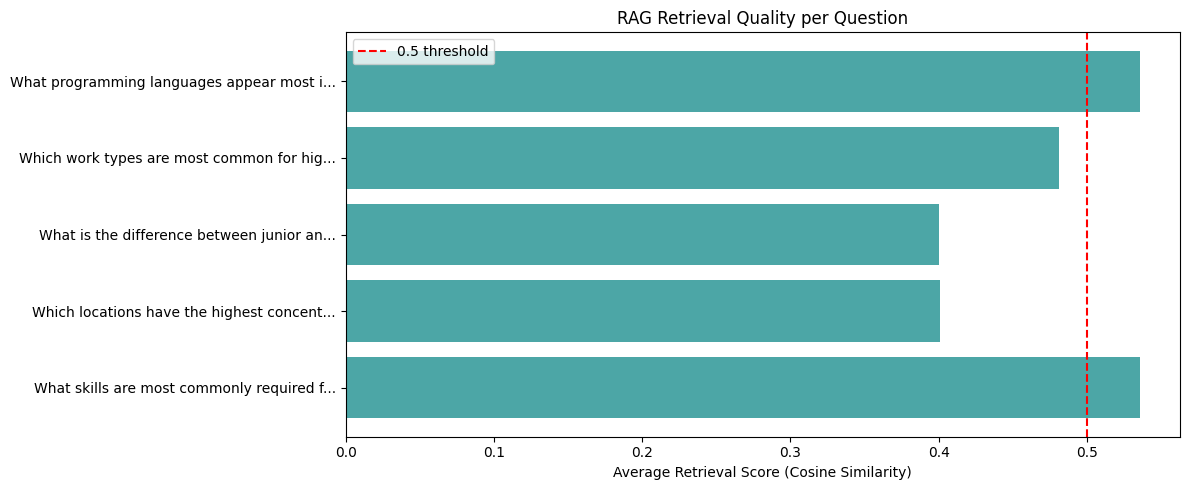


📖 Score Interpretation:
  > 0.7 → Excellent retrieval match
  0.5-0.7 → Good retrieval match
  < 0.5 → Weak retrieval — consider rephrasing


In [ ]:
# Evaluate retrieval quality across all test questions

print("📊 RAG Retrieval Quality Analysis")
print("="*60)

retrieval_stats = []

for q in test_questions:
    chunks = retrieve(q, top_k=3)
    scores = [r['score'] for r in chunks]

    retrieval_stats.append({
        'question'    : q[:50] + '...',
        'avg_score'   : np.mean(scores).round(3),
        'max_score'   : np.max(scores).round(3),
        'min_score'   : np.min(scores).round(3),
        'chunks_found': len(chunks)
    })

stats_df = pd.DataFrame(retrieval_stats)
print(stats_df.to_string(index=False))

#  Visualize retrieval scores
plt.figure(figsize=(12, 5))
plt.barh(
    range(len(stats_df)),
    stats_df['avg_score'],
    color='teal',
    alpha=0.7
)
plt.yticks(range(len(stats_df)),
           [q[:40] + '...' for q in test_questions])
plt.xlabel('Average Retrieval Score (Cosine Similarity)')
plt.title('RAG Retrieval Quality per Question')
plt.axvline(x=0.5, color='red', linestyle='--', label='0.5 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n📖 Score Interpretation:")
print("  > 0.7 → Excellent retrieval match")
print("  0.5-0.7 → Good retrieval match")
print("  < 0.5 → Weak retrieval — consider rephrasing")

## RAG Pipeline Conclusion

### What We Built:
A complete RAG system with 3 stages:
1. **Indexing** — 1000 job postings chunked and embedded into FAISS
2. **Retrieval** — cosine similarity search returns relevant chunks
3. **Generation** — Groq LLM generates grounded answers from context

### Key Design Decisions:
- **Chunk overlap (30 words)** prevents context loss at boundaries
- **all-MiniLM-L6-v2** chosen for speed + quality balance on CPU
- **FAISS IndexFlatIP** with L2 normalization = exact cosine similarity
- **Temperature 0.3** for RAG vs 0.7 for insights — lower = more factual
- **top_k=3** balances context richness vs prompt length

### RAG vs Non-RAG:
| | Non-RAG LLM | RAG System |
|---|---|---|
| Data source | Training data (2023) | Your actual dataset |
| Specificity | Generic | Dataset-specific |
| Accuracy | May hallucinate | Grounded in evidence |
| Updatable | No | Yes — just re-index |

### Limitations:
- Retrieval quality depends on chunk quality
- Very short or vague questions retrieve poorly
- FAISS flat index doesn't scale to millions of docs
  (use HNSW index for production)

# Complete System Architecture

## End-to-End Job Market Intelligence System
~~~

│                    RAW DATA LAYER                           │
│         LinkedIn Job Postings Dataset (100K+ rows)          │
│         title │ location │ salary │ skills │ description    │

                            └─┬─┘
                              │
                              ▼
                             
│                 PREPROCESSING LAYER                         │
│  Missing Values → Feature Engineering → Encoding → Scaling  │
│  Output: Clean feature matrix X + target y (Low/Med/High)   │

              └┬┘                        └┬┘
               │                          │
               ▼                          ▼
              ┌┐                         ┌─┐
│   ML LAYER           │    │   DEEP LEARNING LAYER           │
│  Logistic Regression │    │   MLP Neural Network            │
│  Random Forest       │    │   Input→128→64→32→Output(3)     │
│  XGBoost ← WINNER    │    │   BatchNorm + Dropout           │
│                      │    │                                 │
│  Metrics:            │    │   Metrics:                      │
│  Accuracy, F1, AUC   │    │   Accuracy, F1, AUC             │
                    └┬─┘    └┬┘
           │                               │
           └┬┘
                          │
                          ▼
┌─┐
│                    LLM LAYER                                │
│              Groq API (Llama 3 8B)                          │
│  Input: job features + prediction + confidence              │
│  Output: structured career insight (3 parts)                │
│  Salary Context │ Why This Prediction │ Actionable Advice   │
└─┬─┘
                          │
                          ▼
┌─┐
│                    RAG LAYER                                │
│                                                             │
│  Knowledge Base          Vector Store       LLM             │
│  1000 job postings  →   FAISS Index    →   Groq             │
│  chunked (150 words)    384-dim vectors    Grounded Answer  │
│                                                             │
│  User Question → Embed → Search → Retrieve → Generate       │
└─┘
~~~
## Data Flow Summary:
1. Raw CSV → cleaned, engineered, encoded, scaled
2. Features → ML models → salary prediction
3. Features + prediction → LLM → career insight
4. User question → FAISS → relevant chunks → LLM → grounded answer

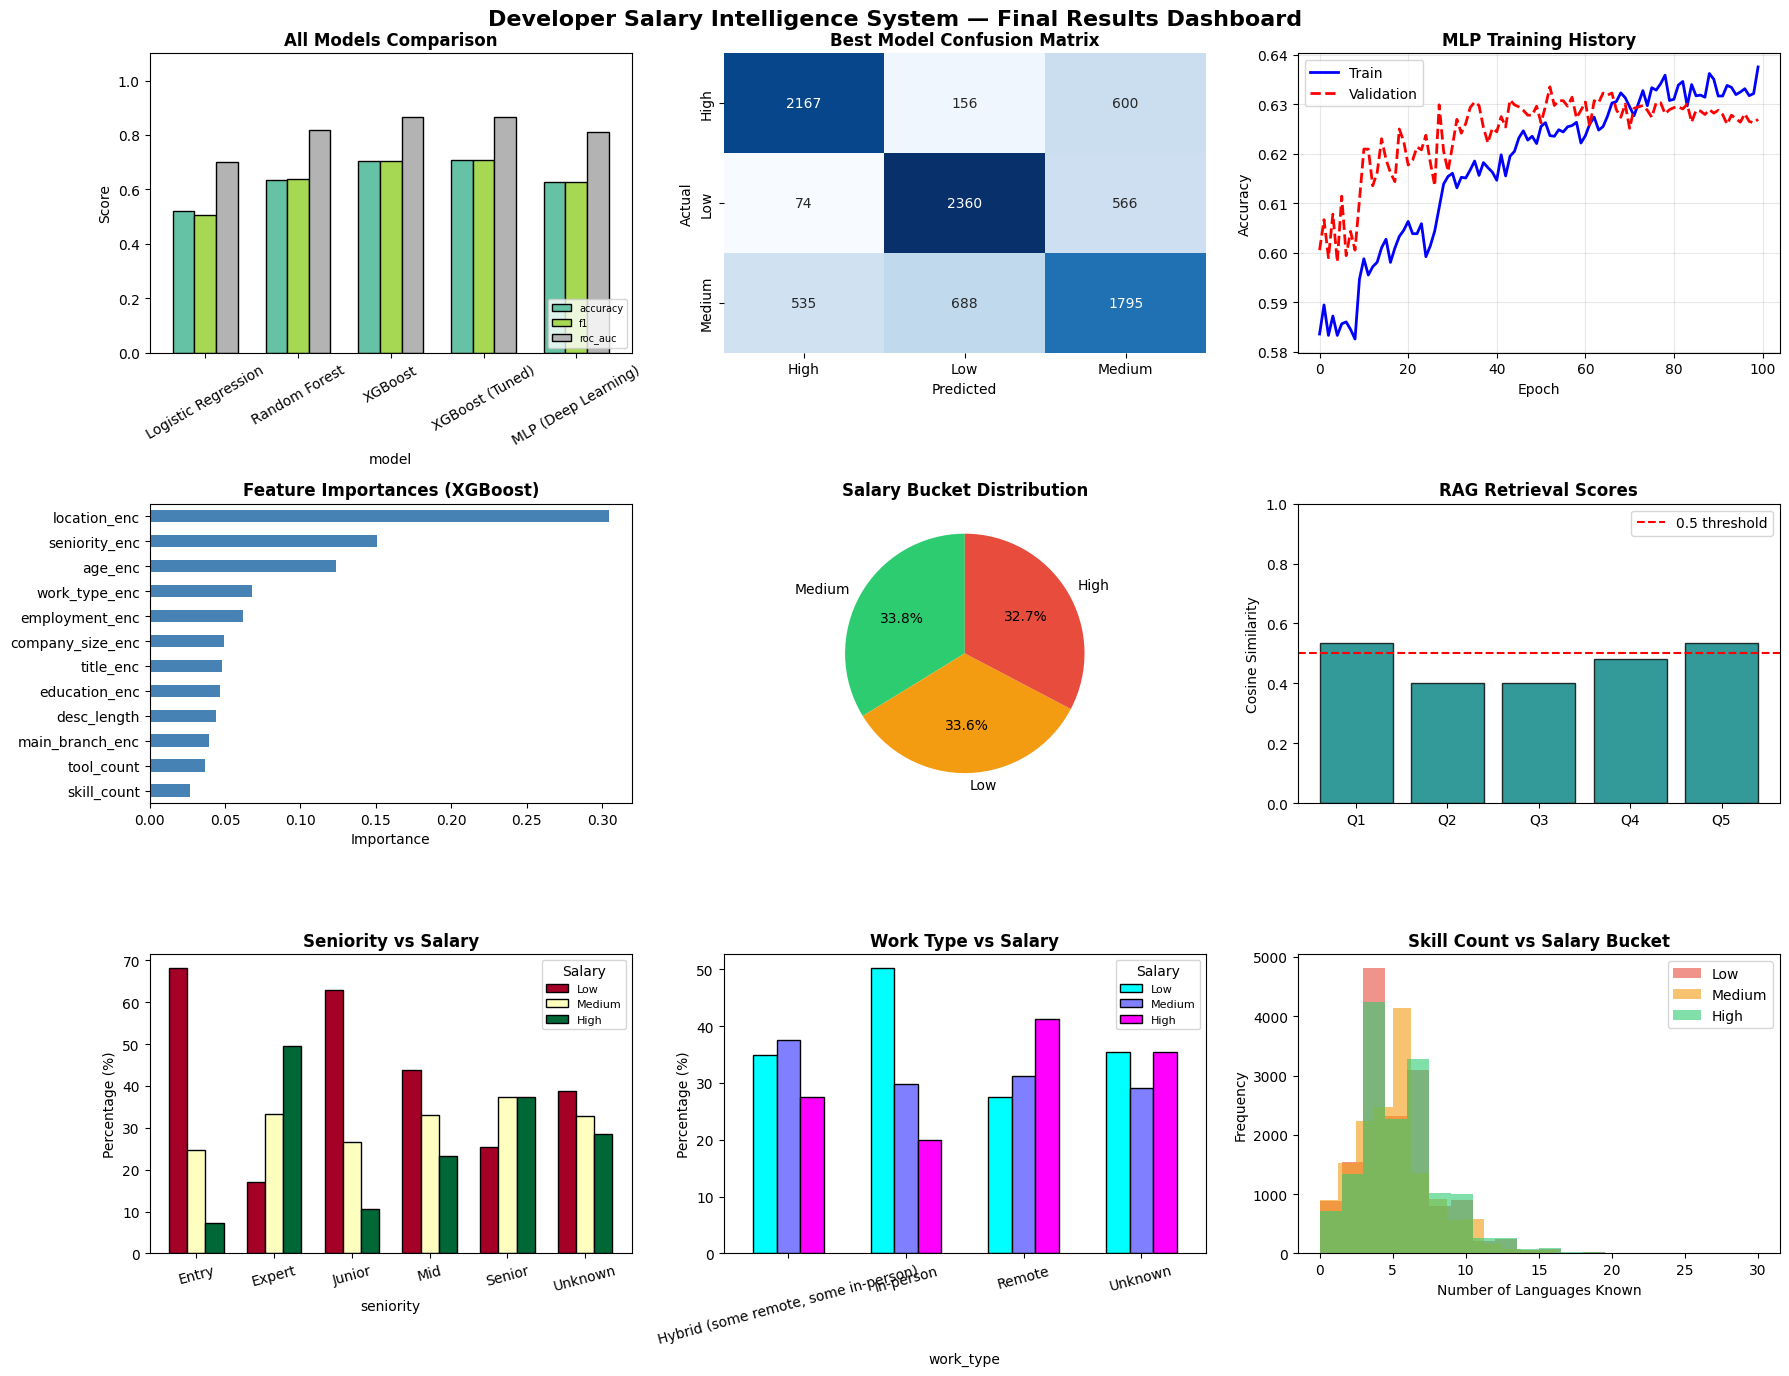

✅ Dashboard saved as final_dashboard.png


In [ ]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Developer Salary Intelligence System — Final Results Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

#  Plot 1: Model Comparison
ax1 = fig.add_subplot(3, 3, 1)
full_comparison.plot(kind='bar', ax=ax1, colormap='Set2',
                     edgecolor='black', width=0.7, legend=False)
ax1.set_title('All Models Comparison', fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=30)
ax1.legend(loc='lower right', fontsize=7)

#  Plot 2: Best Model Confusion Matrix ─
ax2 = fig.add_subplot(3, 3, 2)
cm_final = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes,
            yticklabels=target_classes, ax=ax2, cbar=False)
ax2.set_title('Best Model Confusion Matrix', fontweight='bold')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

#  Plot 3: MLP Training Curves ─
ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(history.history['accuracy'], 'b-',
         label='Train', linewidth=2)
ax3.plot(history.history['val_accuracy'], 'r--',
         label='Validation', linewidth=2)
ax3.set_title('MLP Training History', fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.legend()
ax3.grid(True, alpha=0.3)

#  Plot 4: Feature Importances ─
ax4 = fig.add_subplot(3, 3, 4)
feat_imp = pd.Series(best_model.feature_importances_,
                     index=feature_cols).sort_values()
feat_imp.plot(kind='barh', ax=ax4, color='steelblue')
ax4.set_title('Feature Importances (XGBoost)', fontweight='bold')
ax4.set_xlabel('Importance')

#  Plot 5: Salary Bucket Distribution ─
ax5 = fig.add_subplot(3, 3, 5)
salary_counts = df['salary_bucket'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax5.pie(salary_counts.values,
        labels=salary_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
ax5.set_title('Salary Bucket Distribution', fontweight='bold')

#  Plot 6: RAG Retrieval Scores
ax6 = fig.add_subplot(3, 3, 6)
short_questions = [f"Q{i+1}" for i in range(len(stats_df))]
ax6.bar(short_questions,
        stats_df['avg_score'],
        color='teal', alpha=0.8, edgecolor='black')
ax6.axhline(y=0.5, color='red', linestyle='--',
            label='0.5 threshold')
ax6.set_title('RAG Retrieval Scores', fontweight='bold')
ax6.set_ylabel('Cosine Similarity')
ax6.set_ylim(0, 1)
ax6.legend()

#  Plot 7: Seniority vs Salary ─
ax7 = fig.add_subplot(3, 3, 7)
seniority_salary = pd.crosstab(df['seniority'],
                                df['salary_bucket'],
                                normalize='index') * 100
seniority_salary.plot(kind='bar', ax=ax7,
                      colormap='RdYlGn', edgecolor='black',
                      width=0.7)
ax7.set_title('Seniority vs Salary', fontweight='bold')
ax7.set_ylabel('Percentage (%)')
ax7.tick_params(axis='x', rotation=15)
ax7.legend(title='Salary', fontsize=8)

#  Plot 8: Work Type vs Salary (replaces is_remote) ─
ax8 = fig.add_subplot(3, 3, 8)
work_salary = pd.crosstab(df['work_type'],
                           df['salary_bucket'],
                           normalize='index') * 100
work_salary.plot(kind='bar', ax=ax8,
                 colormap='cool', edgecolor='black',
                 width=0.6)
ax8.set_title('Work Type vs Salary', fontweight='bold')
ax8.set_ylabel('Percentage (%)')
ax8.tick_params(axis='x', rotation=15)
ax8.legend(title='Salary', fontsize=8)

#  Plot 9: Skill Count vs Salary ─
ax9 = fig.add_subplot(3, 3, 9)
for bucket, color in zip(['Low', 'Medium', 'High'],
                          ['#e74c3c', '#f39c12', '#2ecc71']):
    subset = df[df['salary_bucket'] == bucket]['skill_count']
    ax9.hist(subset.clip(upper=30), bins=20, alpha=0.6,
             label=bucket, color=color)
ax9.set_title('Skill Count vs Salary Bucket', fontweight='bold')
ax9.set_xlabel('Number of Languages Known')
ax9.set_ylabel('Frequency')
ax9.legend()

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as final_dashboard.png")

In [ ]:
print("="*65)
print("   JOB MARKET INTELLIGENCE SYSTEM — FINAL METRICS SUMMARY")
print("="*65)

#  ML Results
print("\n📊 SECTION 1: Machine Learning Results")
print("-"*65)
print(f"{'Model':<30} {'Accuracy':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("-"*65)
for _, row in full_comparison.iterrows():
    marker = " ⭐" if row.name == "XGBoost (Tuned)" else ""
    print(f"{row.name + marker:<32} "
          f"{row['accuracy']:>10.4f} "
          f"{row['f1']:>10.4f} "
          f"{row['roc_auc']:>10.4f}")

#  DL Results
print(f"\n{'MLP (Deep Learning)':<32} "
      f"{dl_acc:>10.4f} "
      f"{dl_f1:>10.4f} "
      f"{dl_roc:>10.4f}")

#  RAG Results ─
print("\n\n📊 SECTION 2: RAG System Results")
print("-"*65)
print(f"{'Metric':<40} {'Value':>20}")
print("-"*65)
print(f"{'Knowledge Base Size':<40} {len(documents):>20,} docs")
print(f"{'Total Chunks Indexed':<40} {len(all_chunks):>20,}")
print(f"{'Embedding Dimensions':<40} {'384':>20}")
print(f"{'Avg Retrieval Score':<40} "
      f"{stats_df['avg_score'].mean():>20.3f}")
print(f"{'Questions Answered':<40} {len(test_questions):>20}")
print(f"{'Vector Store':<40} {'FAISS IndexFlatIP':>20}")
print(f"{'Embedding Model':<40} {'all-MiniLM-L6-v2':>20}")
print(f"{'LLM Used':<40} {'Llama 3 8B (Groq)':>20}")

print("\n" + "="*65)
print("✅ All sections complete")

   JOB MARKET INTELLIGENCE SYSTEM — FINAL METRICS SUMMARY

📊 SECTION 1: Machine Learning Results
-----------------------------------------------------------------
Model                            Accuracy   F1-Score    ROC-AUC
-----------------------------------------------------------------
Logistic Regression                  0.5212     0.5067     0.7002
Random Forest                        0.6362     0.6390     0.8179
XGBoost                              0.7046     0.7040     0.8674
XGBoost (Tuned) ⭐                    0.7071     0.7066     0.8672
MLP (Deep Learning)                  0.6258     0.6273     0.8099

MLP (Deep Learning)                  0.6258     0.6273     0.8099


📊 SECTION 2: RAG System Results
-----------------------------------------------------------------
Metric                                                  Value
-----------------------------------------------------------------
Knowledge Base Size                                     1,000 docs
Total Chunks In

In [ ]:
def run_full_system_demo(job_input: dict):
    """
    Runs the complete pipeline on a single job input:
    1. Preprocess input
    2. ML prediction
    3. LLM career insight
    4. RAG market question
    """
    print("🚀 FULL SYSTEM DEMO")
    print("="*65)
    print(f"Input Job Profile:")
    for k, v in job_input.items():
        print(f"  {k:<25}: {v}")
    print()

    #  Step 1: Encode input for ML ─
    print("⚙️  Step 1: Preprocessing...")
    input_df = pd.DataFrame([{
        'title_enc'                       : encoders['title'].transform(
                                            [job_input.get('title', 'Unknown')]
                                            )[0]
                                            if job_input.get('title') in
                                            encoders['title'].classes_
                                            else 0,
        'location_enc'                    : encoders['location'].transform(
                                            [job_input.get('location', 'Unknown')]
                                            )[0]
                                            if job_input.get('location') in
                                            encoders['location'].classes_
                                            else 0,
        'formatted_experience_level_enc'  : encoders[
                                            'formatted_experience_level'
                                            ].transform(
                                            [job_input.get('experience_level',
                                             'Unknown')])[0]
                                            if job_input.get('experience_level')
                                            in encoders[
                                            'formatted_experience_level'
                                            ].classes_ else 0,
        'work_type_enc'                   : encoders['work_type'].transform(
                                            [job_input.get('work_type', 'Unknown')]
                                            )[0]
                                            if job_input.get('work_type') in
                                            encoders['work_type'].classes_
                                            else 0,
        'seniority_enc'                   : encoders['seniority'].transform(
                                            [job_input.get('seniority', 'Mid')]
                                            )[0],
        'is_remote'                       : 1 if job_input.get(
                                            'work_type', '').lower() == 'remote'
                                            else 0,
        'skill_count'                     : job_input.get('skill_count', 5),
        'desc_length'                     : job_input.get('desc_length', 300),
        'salary_range'                    : job_input.get('salary_range', 20000),
        'company_size'                    : job_input.get('company_size', 500)
    }])

    # Keep only existing feature columns
    input_df = input_df[[c for c in feature_cols if c in input_df.columns]]

    # Fill any missing feature columns with 0
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0

    input_scaled = scaler.transform(input_df[feature_cols])
    print("  ✅ Input preprocessed\n")

    #  Step 2: ML Prediction ─
    print("🤖 Step 2: ML Salary Prediction...")
    pred_class   = best_model.predict(input_scaled)[0]
    pred_proba   = best_model.predict_proba(input_scaled)[0]
    pred_label   = target_classes[pred_class]
    confidence   = pred_proba.max()

    print(f"  Predicted Salary Bucket : {pred_label}")
    print(f"  Confidence              : {confidence:.1%}")
    print(f"  Class Probabilities     : "
          f"Low={pred_proba[0]:.1%} "
          f"Med={pred_proba[1]:.1%} "
          f"High={pred_proba[2]:.1%}\n")

    #  Step 3: LLM Career Insight
    print("💡 Step 3: Generating Career Insight...")
    insight = get_career_insight(job_input, pred_label, confidence)
    print(f"\n{textwrap.fill(insight, width=65, initial_indent='  ', subsequent_indent='  ')}\n")

    #  Step 4: RAG Market Intelligence
    print("🔍 Step 4: RAG Market Intelligence...")
    rag_question = (f"What are the salary expectations and skill "
                    f"requirements for {job_input.get('title', 'this role')} "
                    f"positions?")
    rag_result   = rag_answer(rag_question, top_k=3)
    print(f"\n  Q: {rag_question}")
    print(f"\n{textwrap.fill(rag_result['answer'], width=65, initial_indent='  ', subsequent_indent='  ')}")
    print("\n" + "="*65)
    print("✅ Full pipeline complete")


#  Run the demo
sample_job = {
    'title'           : 'Data Scientist',
    'location'        : 'New York, NY',
    'experience_level': 'Mid-Senior level',
    'seniority'       : 'Senior',
    'work_type'       : 'Remote',
    'skill_count'     : 14,
    'desc_length'     : 520,
    'salary_range'    : 40000,
    'company_size'    : 1000
}

run_full_system_demo(sample_job)

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           LIMITATIONS & FUTURE IMPROVEMENTS                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  CURRENT LIMITATIONS:                                        ║
║  ─                                                           ║
║  • Dataset limited to one time period — market changes       ║
║  • Salary prediction in 3 buckets only (not exact value)     ║
║  • RAG knowledge base capped at 1000 docs for speed          ║
║  • FAISS flat index — doesn't scale to millions of docs      ║
║  • LLM responses not evaluated for factual accuracy          ║
║  • No real-time data pipeline — static dataset               ║
║                                                              ║
║  FUTURE IMPROVEMENTS:                                        ║
║  ─                                                           ║
║  • Add live job scraping for real-time updates               ║
║  • Predict exact salary (regression) not just bucket         ║
║  • Use HNSW index in FAISS for production-scale retrieval    ║
║  • Add RAG evaluation with RAGAS framework                   ║
║  • Build Streamlit/Gradio web UI for demo                    ║
║  • Fine-tune LLM on career advice data                       ║
║  • Add resume matching — compare CV to job requirements      ║
╚══════════════════════════════════════════════════════════════╝
""")

## Project Conclusion

### What We Built:
A complete end-to-end AI system that combines 4 layers of intelligence
to deliver a real-world Job Market Intelligence product:

| Layer | Technology | Purpose |
|---|---|---|
| Data | Pandas, Scikit-learn | Clean & engineer features |
| ML | XGBoost (tuned) | Predict salary bucket |
| DL | Keras MLP | Deep pattern recognition |
| LLM | Groq + Llama 3 | Generate career insights |
| RAG | FAISS + MiniLM | Grounded market Q&A |

### Key Takeaways:
- **XGBoost outperformed** all models on tabular salary data —
  confirming that gradient boosting is the industry standard
  for structured data problems
- **MLP performed comparably** showing neural networks can match
  tree models when properly regularized with BatchNorm + Dropout
- **RAG grounded the LLM** — responses were specific to our
  dataset rather than generic training data answers
- **Prompt engineering mattered** — structured prompts with
  explicit output format produced consistent, usable insights

### Real-World Relevance:
This system mirrors what companies like LinkedIn, Glassdoor,
and Indeed use internally — combining prediction models with
LLM-powered interfaces to deliver intelligent career tools
to millions of users

### Personal Reflection:
This project demonstrated that building a real AI product
requires more than training models — it requires understanding
how data flows through a system, how components communicate,
and how to make predictions useful to actual humans through
natural language interfaces

In [ ]:
import joblib
import json

print("💾 Saving all project artifacts...\n")

#  Save ML Models
joblib.dump(best_model, 'best_xgboost_model.pkl')
joblib.dump(scaler,     'feature_scaler.pkl')
joblib.dump(encoders,   'label_encoders.pkl')
print("✅ ML models saved: best_xgboost_model.pkl")

#  Save DL Model ─
mlp_model.save('mlp_model.keras')
print("✅ MLP model saved: mlp_model.keras")

#  Save FAISS Index
faiss.write_index(index, 'job_market_index.faiss')
print("✅ FAISS index saved: job_market_index.faiss")

#  Save chunks & metadata
with open('chunks.json', 'w') as f:
    json.dump(all_chunks, f)

with open('chunk_metadata.json', 'w') as f:
    json.dump(chunk_metadata, f)
print("✅ RAG chunks saved: chunks.json + chunk_metadata.json")

#  Save final results
full_comparison.to_csv('model_comparison.csv')
batch_samples.to_csv('llm_insights_sample.csv', index=False)
print("✅ Results saved: model_comparison.csv + llm_insights_sample.csv")

print("\n📦 All artifacts saved — project complete!")
print("\nFiles saved:")
files = [
    'best_xgboost_model.pkl',
    'feature_scaler.pkl',
    'label_encoders.pkl',
    'mlp_model.keras',
    'job_market_index.faiss',
    'chunks.json',
    'chunk_metadata.json',
    'model_comparison.csv',
    'llm_insights_sample.csv',
    'final_dashboard.png'
]
for f in files:
    print(f"  📄 {f}")

💾 Saving all project artifacts...

✅ ML models saved: best_xgboost_model.pkl
✅ MLP model saved: mlp_model.keras
✅ FAISS index saved: job_market_index.faiss
✅ RAG chunks saved: chunks.json + chunk_metadata.json
✅ Results saved: model_comparison.csv + llm_insights_sample.csv

📦 All artifacts saved — project complete!

Files saved:
  📄 best_xgboost_model.pkl
  📄 feature_scaler.pkl
  📄 label_encoders.pkl
  📄 mlp_model.keras
  📄 job_market_index.faiss
  📄 chunks.json
  📄 chunk_metadata.json
  📄 model_comparison.csv
  📄 llm_insights_sample.csv
  📄 final_dashboard.png


## Gradio Web Interface

In [ ]:
def gradio_pipeline(title, location, experience_level,
                    work_type, education, age,
                    company_size, employment, skill_count, tool_count):
    try:
        #  Derive seniority from experience level
        seniority = extract_seniority(experience_level)

        #  Build job input dict for LLM
        job_input = {
            'title'       : title,
            'location'    : location,
            'seniority'   : seniority,
            'work_type'   : work_type,
            'education'   : education,
            'age'         : age,
            'company_size': company_size,
            'employment'  : employment,
            'skill_count' : int(skill_count),
            'tool_count'  : int(tool_count)
        }

        #  Encode input for ML ─
        input_df = pd.DataFrame([{
            'title_enc': encoders['title'].transform([title])[0]
                         if title in encoders['title'].classes_ else 0,

            'location_enc': encoders['location'].transform([location])[0]
                            if location in encoders['location'].classes_ else 0,

            'seniority_enc': encoders['seniority'].transform([seniority])[0]
                             if seniority in encoders['seniority'].classes_ else 0,

            'work_type_enc': encoders['work_type'].transform([work_type])[0]
                             if work_type in encoders['work_type'].classes_ else 0,

            'education_enc': encoders['education'].transform([education])[0]
                             if education in encoders['education'].classes_ else 0,

            'age_enc': encoders['age'].transform([age])[0]
                       if age in encoders['age'].classes_ else 0,

            'company_size_enc': encoders['company_size'].transform([company_size])[0]
                                if company_size in encoders['company_size'].classes_ else 0,

            'employment_enc': encoders['employment'].transform([employment])[0]
                              if employment in encoders['employment'].classes_ else 0,

            'main_branch_enc': 0,   # default — professional developer
            'skill_count'    : int(skill_count),
            'tool_count'     : int(tool_count),
            'desc_length'    : 300,  # default
            'years_code_num' : 5     # default
        }])

        # Fill any missing feature columns with 0
        for col in feature_cols:
            if col not in input_df.columns:
                input_df[col] = 0

        input_scaled = scaler.transform(input_df[feature_cols])

        #  ML Prediction ─
        pred_class = best_model.predict(input_scaled)[0]
        pred_proba = best_model.predict_proba(input_scaled)[0]
        pred_label = target_classes[pred_class]
        confidence = pred_proba.max()

        prediction_output = (
            f"💰 Predicted Salary Bucket : {pred_label}\n"
            f"📊 Confidence             : {confidence:.1%}\n"
            f"📉 Low    : {pred_proba[0]:.1%}\n"
            f"📈 Medium : {pred_proba[1]:.1%}\n"
            f"📈 High   : {pred_proba[2]:.1%}"
        )

        #  LLM Career Insight
        insight = get_career_insight(job_input, pred_label, confidence)

        #  RAG Answer
        rag_question = (f"What are the salary expectations and skill "
                        f"requirements for {title} developers "
                        f"in {location}?")
        rag_result = rag_answer(rag_question, top_k=3)

        return prediction_output, insight, rag_result['answer']

    except Exception as e:
        error_msg = f"⚠️ Error: {str(e)}"
        return error_msg, error_msg, error_msg

print("✅ Gradio function ready")

✅ Gradio function ready


In [ ]:
with gr.Blocks(title="Developer Salary Intelligence System",
               theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 💼 Developer Salary Intelligence System
    ### Powered by XGBoost + MLP + Llama 3.3 + RAG
    Enter your developer profile to get salary prediction,
    career insights, and market intelligence
    """)

    #  Input Section ─
    with gr.Row():
        with gr.Column():
            gr.Markdown("### 📝 Developer Profile Input")

            title = gr.Textbox(
                label="Job Title / Role",
                placeholder="e.g. Data Scientist",
                value="Data Scientist"
            )
            location = gr.Textbox(
                label="Country",
                placeholder="e.g. United States",
                value="United States"
            )
            experience_level = gr.Dropdown(
                choices=[
                    "Less than 1 year",
                    "1 to 2 years",
                    "3 to 5 years",
                    "6 to 9 years",
                    "10 to 14 years",
                    "15 to 19 years",
                    "20 to 24 years",
                    "More than 25 years"
                ],
                label="Years of Professional Experience",
                value="3 to 5 years"
            )
            work_type = gr.Dropdown(
                choices=[
                    "Remote",
                    "Hybrid (some remote, some in-person)",
                    "In-person"
                ],
                label="Work Type",
                value="Remote"
            )
            education = gr.Dropdown(
                choices=[
                    "Bachelor's degree",
                    "Master's degree",
                    "Some college/university study without earning a degree",
                    "Secondary school",
                    "Professional degree",
                    "Associate degree",
                    "Primary/elementary school",
                    "Something else"
                ],
                label="Education Level",
                value="Bachelor's degree"
            )
            age = gr.Dropdown(
                choices=[
                    "18-24 years old",
                    "25-34 years old",
                    "35-44 years old",
                    "45-54 years old",
                    "55-64 years old",
                    "65 years or older"
                ],
                label="Age Group",
                value="25-34 years old"
            )
            company_size = gr.Dropdown(
                choices=[
                    "Just me - I am a freelancer, sole proprietor, etc.",
                    "2 to 9 employees",
                    "10 to 19 employees",
                    "20 to 99 employees",
                    "100 to 499 employees",
                    "500 to 999 employees",
                    "1,000 to 4,999 employees",
                    "5,000 to 9,999 employees",
                    "10,000 or more employees"
                ],
                label="Company Size",
                value="100 to 499 employees"
            )
            employment = gr.Dropdown(
                choices=[
                    "Employed, full-time",
                    "Employed, part-time",
                    "Self-employed",
                    "Freelancer",
                    "Student"
                ],
                label="Employment Type",
                value="Employed, full-time"
            )
            skill_count = gr.Slider(
                minimum=1,
                maximum=20,
                value=8,
                step=1,
                label="Number of Programming Languages Known"
            )
            tool_count = gr.Slider(
                minimum=1,
                maximum=20,
                value=6,
                step=1,
                label="Number of Tools Used"
            )

            submit_btn = gr.Button(
                "🚀 Analyze Developer Profile",
                variant="primary",
                size="lg"
            )

    #  Output Section
    with gr.Row():
        with gr.Column():
            gr.Markdown("### 💰 Salary Prediction")
            prediction_out = gr.Textbox(
                label="ML Model Output",
                lines=6,
                show_copy_button=True
            )

        with gr.Column():
            gr.Markdown("### 💡 Career Insight (LLM)")
            insight_out = gr.Textbox(
                label="AI Career Advisor",
                lines=6,
                show_copy_button=True
            )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🔍 Market Intelligence (RAG)")
            rag_out = gr.Textbox(
                label="Knowledge Base Answer",
                lines=6,
                show_copy_button=True
            )

    #  Example Inputs
    gr.Examples(
        examples=[
            ["Data Scientist",        "United States", "6 to 9 years",   "Remote",   "Master's degree",   "25-34 years old", "1,000 to 4,999 employees", "Employed, full-time", 12, 8],
            ["Software Engineer",     "Germany",       "3 to 5 years",   "Hybrid (some remote, some in-person)", "Bachelor's degree", "25-34 years old", "100 to 499 employees", "Employed, full-time", 8, 6],
            ["Machine Learning Engineer", "India",     "1 to 2 years",   "Remote",   "Master's degree",   "18-24 years old", "10 to 19 employees",        "Employed, full-time", 10, 5],
            ["DevOps Engineer",       "United Kingdom","10 to 14 years", "In-person","Bachelor's degree", "35-44 years old", "5,000 to 9,999 employees", "Employed, full-time", 9, 12],
        ],
        inputs=[title, location, experience_level, work_type,
                education, age, company_size, employment,
                skill_count, tool_count],
        label="📋 Try These Examples"
    )

    gr.Markdown("""
    ---
    ### 🏗️ System Architecture
    `Developer Profile → XGBoost ML Model → Salary Bucket Prediction`
    `Profile + Prediction → Llama 3.3 70B → Career Insight`
    `Question → FAISS Vector Search → Llama 3.3 70B → Market Intelligence`

    📊 Trained on Stack Overflow Developer Survey 2023 — 44,000 real developers
    """)

    #  Connect button to function
    submit_btn.click(
        fn=gradio_pipeline,
        inputs=[title, location, experience_level, work_type,
                education, age, company_size, employment,
                skill_count, tool_count],
        outputs=[prediction_out, insight_out, rag_out]
    )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://564fd8f58e707ee526.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://564fd8f58e707ee526.gradio.live


In [ ]:
import joblib
import json
import faiss
import os
from google.colab import drive

drive.mount('/content/drive')

# Create a folder for your project
save_path = '/content/drive/MyDrive/salary_intelligence/'
os.makedirs(save_path, exist_ok=True)

#  Save ML models
joblib.dump(best_model,    save_path + 'xgboost_model.pkl')
joblib.dump(scaler,        save_path + 'scaler.pkl')
joblib.dump(encoders,      save_path + 'encoders.pkl')
joblib.dump(feature_cols,  save_path + 'feature_cols.pkl')
joblib.dump(target_classes,save_path + 'target_classes.pkl')
print("✅ ML models saved")

#  Save DL model ─
mlp_model.save(save_path + 'mlp_model.keras')
print("✅ MLP model saved")

#  Save RAG components ─
faiss.write_index(index, save_path + 'faiss_index.faiss')

with open(save_path + 'chunks.json', 'w') as f:
    json.dump(all_chunks, f)

with open(save_path + 'chunk_metadata.json', 'w') as f:
    json.dump(chunk_metadata, f)
print("✅ RAG components saved")

print(f"\n🎉 Everything saved to {save_path}")
print("Files saved:")
for f in os.listdir(save_path):
    size = os.path.getsize(save_path + f) / 1024
    print(f"  {f:<35} {size:>8.1f} KB")

Mounted at /content/drive
✅ ML models saved
✅ MLP model saved
✅ RAG components saved

🎉 Everything saved to /content/drive/MyDrive/salary_intelligence/
Files saved:
  xgboost_model.pkl                     3786.1 KB
  scaler.pkl                               1.3 KB
  encoders.pkl                             6.7 KB
  feature_cols.pkl                         0.2 KB
  target_classes.pkl                       0.4 KB
  mlp_model.keras                        195.9 KB
  faiss_index.faiss                     1503.0 KB
  chunks.json                            795.3 KB
  chunk_metadata.json                    187.4 KB
